# Experiment 02 (70-Run)

Systematic evaluation of 70 mine-to-port road scenarios connecting Cameroon's mines to Kribi port.

**Factorial design:** 2 mining scopes × 7 friction layers × 5 spatial masks = 70 scenarios

| Dimension | Options |
|---|---|
| **Mining scope** | Late-stage only (11 mines); Late + Early-stage (29 mines) |
| **Friction layer** | Construction cost only; Carbon (low); Carbon (central); Carbon (high); Carbon (low) + BII; Carbon (central) + BII; Carbon (high) + BII |
| **Spatial mask** | No mask; Protected areas; Protected areas + 3 km buffer; Protected areas + 5 km buffer; Protected areas + 10 km buffer |

Metrics: road km, construction cost (USD), deforestation risk, forest fragmentation.

## Friction Layers and Shadow Price Formulation

This study tests seven friction layers. The baseline (`construction_only`) uses engineering construction cost only. The remaining six layers add **shadow prices** on top. The shadow prices are defined based on monetized estimates of permanent environmental damage from road construction.

Two damage components are included:

**Carbon damage**: cost of releasing stored forest carbon, scaled by local tree cover:

$$C_i^{\text{carbon}} = A_i \;\times\; \frac{T_i}{100} \;\times\; \rho_C \;\times\; p_C$$

**Biodiversity damage**: cost of degrading intact habitat, scaled by local biodiversity intactness:

$$C_i^{\text{biodiversity}} = A_i \;\times\; \frac{\mathrm{BII}_i}{100} \;\times\; \beta$$

where $A_i$ = pixel area (ha, latitude-adjusted), $T_i$ = Hansen (2024) tree cover (0–100), $\rho_C$ = carbon density (tCO₂e/ha), $p_C$ = carbon price (USD/tCO₂e), $\mathrm{BII}_i$ = Biodiversity Intactness Index (NHM v2.1.1, 2020; 0–100 scale), and $\beta$ = biodiversity base value (USD/ha).

The total friction at pixel $i$:

$$C_i = C_i^{\text{construction}} + C_i^{\text{carbon}} + C_i^{\text{biodiversity}}$$

| Layer | Carbon price | Biodiversity | Mean shadow (USD/px) | Mean total (USD/px) |
|---|---|---|---|---|
| `construction_only` | — | — | $0 | $107,206 |
| `carbon_low` | 5 USD/tCO₂e × $\rho_C$ × $T_i$ | — | $730 | $107,936 |
| `carbon_central` | 40 USD/tCO₂e × $\rho_C$ × $T_i$ | — | $5,840 | $113,046 |
| `carbon_high` | 90 USD/tCO₂e × $\rho_C$ × $T_i$ | — | $13,140 | $120,346 |
| `carbon_low__biodiversity` | 5 USD/tCO₂e × $\rho_C$ × $T_i$ | $80,920/ha × BII | $32,779 | $139,985 |
| `carbon_central__biodiversity` | 40 USD/tCO₂e × $\rho_C$ × $T_i$ | $80,920/ha × BII | $37,889 | $145,095 |
| `carbon_high__biodiversity` | 90 USD/tCO₂e × $\rho_C$ × $T_i$ | $80,920/ha × BII | $45,189 | $152,395 |

### Sources of Parameter Values

- **Carbon density ($\rho_C$ = 550 tCO₂e/ha):** [Saatchi et al. (2011)](https://doi.org/10.1073/pnas.1019576108) Table 1 reports Cameroon carbon density by canopy threshold: 129 MgC/ha (10% threshold) → 473 tCO₂e/ha; 142 MgC/ha (25%) → 521 tCO₂e/ha; 151 MgC/ha (30%) → 554 tCO₂e/ha. The conversion from MgC/ha to tCO₂e uses the 44/12 molecular weight ratio of CO₂ to C (≈ 3.667). The [IPCC AFOLU Tier 1 default (2006, Table 4.7)](https://www.ipcc-nggip.iges.or.jp/public/2006gl/vol4.html) gives 310 tDM/ha AGB for tropical rain forest in Africa; applying the carbon fraction 0.47 (IPCC Table 2.2) and the same conversion: 310 × 0.47 × 3.667 = 534 tCO₂e/ha. Both sources converge around 534–554 tCO₂e/ha. Because mean tree cover in Cameroon is approximately 70%, the denser-forest end of Saatchi's range (30% canopy threshold, 554 tCO₂e/ha) is most representative. 550 tCO₂e/ha is adopted as a round figure consistent with both references.

- **Carbon price tiers:** Three tiers span the plausible policy range. Low (5 USD/tCO₂e) reflects current voluntary carbon market prices. Central (40 USD/tCO₂e) is the midpoint of the 30–50 USD/tCO₂ range estimated as the true cost of high-quality, high-integrity REDD+ implementation, and corresponds to the minimum price required by 2030 to put forest carbon finance on a Paris Agreement-compatible trajectory ([UN-REDD Programme, 2022](https://www.un-redd.org/sites/default/files/2022-11/Forest%20carbon%20pricing%20brief%20-%20FINAL.pdf)). High (90 USD/tCO₂e) reflects the [EU Emissions Trading System (EU ETS)](https://climate.ec.europa.eu/eu-action/eu-emissions-trading-system-eu-ets_en) annual average price in 2023, which is directly relevant given that EU development finance institutions are primary funders of infrastructure projects in Cameroon.

- **Biodiversity base value ($\beta$ ≈ $80,920/ha):** [De Groot et al. (2012)](https://www.sciencedirect.com/science/article/pii/S2212041612000101) report a tropical forest ecosystem service value of **$5,264/ha/year**. Because road construction causes permanent forest loss, this annual flow is capitalized to a net present value (NPV):
  $$\beta = V \times \frac{1 - (1 + r)^{-T}}{r} = 5{,}264 \times \frac{1 - (1.05)^{-30}}{0.05} \approx \$80{,}920\text{/ha}$$
  A discount rate of $r = 5\%$ follows World Bank and AfDB standard practice for infrastructure appraisal in Africa; a time horizon of $T = 30$ years reflects standard road infrastructure lifetime. The $\mathrm{BII}_i/100$ multiplier reduces this penalty proportionally for already-degraded pixels.

- **BII resolution limitation:** The [NHM BII dataset](https://www.nhm.ac.uk/our-science/data/biodiversity-indicators/biodiversity-intactness-index.html) has a native resolution of ~9 km, which is much coarser than the 90 m friction grid. After bilinear resampling, all pixels within the same ~9 km cell receive the same biodiversity penalty. This means the biodiversity component works as a landscape-level signal rather than a corridor-level discriminator. The fine-grained spatial gradient is partially handled by the carbon component through the 30 m Hansen tree cover layer.

**References:** de Groot et al. (2012) *Ecosystem Services* 1:50–61; IPCC (2006) AFOLU Guidelines Tables 2.2 & 4.7; Saatchi et al. (2011) *PNAS* 108(24):9899–9904; UN-REDD Programme (2022) *Pricing Forest Carbon*; EU ETS (2023) annual average spot price.

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display

RESULTS_DIR = Path('../model/results/impact-assessment/experiment_02_70runs')
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

# ── Ordered lists & label maps ────────────────────────────────────────────────
FRICTION_ORDER = [
    'construction_only',
    'carbon_low', 'carbon_central', 'carbon_high',
    'carbon_low__biodiversity', 'carbon_central__biodiversity', 'carbon_high__biodiversity',
]
FRICTION_LABELS = {
    'construction_only':            'Cost only',
    'carbon_low':                   'Carbon (low)',
    'carbon_central':               'Carbon (central)',
    'carbon_high':                  'Carbon (high)',
    'carbon_low__biodiversity':     'Carbon (low) + BII',
    'carbon_central__biodiversity': 'Carbon (central) + BII',
    'carbon_high__biodiversity':    'Carbon (high) + BII',
}
FRICTION_COLORS = {
    'construction_only':            '#636363',
    'carbon_low':                   '#a1d99b',
    'carbon_central':               '#41ab5d',
    'carbon_high':                  '#005a32',
    'carbon_low__biodiversity':     '#fdae6b',
    'carbon_central__biodiversity': '#e6550d',
    'carbon_high__biodiversity':    '#7f2704',
}
MASK_ORDER = [
    'no_mask', 'protected_areas',
    'protected_areas_buf3km', 'protected_areas_buf5km', 'protected_areas_buf10km',
]
MASK_LABELS = {
    'no_mask':                  'No mask',
    'protected_areas':          'PA (0 km)',
    'protected_areas_buf3km':   'PA (3 km)',
    'protected_areas_buf5km':   'PA (5 km)',
    'protected_areas_buf10km':  'PA (10 km)',
}
MINING_ORDER  = ['late_stage', 'late_and_early_stage']
MINING_LABELS = {
    'late_stage':           'Late-stage  (11 mines)',
    'late_and_early_stage': 'Late+Early  (29 mines)',
}
MINING_COLORS = {
    'late_stage':           '#2171b5',
    'late_and_early_stage': '#d94801',
}
SIZE_BINS = [
    ('lt1ha',       '< 1 ha'),
    ('1_10ha',      '1-10 ha'),
    ('10_100ha',    '10-100 ha'),
    ('100_1kha',    '100-1k ha'),
    ('1k_10kha',    '1k-10k ha'),
    ('10k_100kha',  '10k-100k ha'),
    ('100k_1000kha','100k-1M ha'),
    ('gt1000kha',   '> 1M ha'),
]

# ── Helpers ───────────────────────────────────────────────────────────────────
def parse_scenario(name):
    """Extract (mining, friction, mask) from a scenario stem."""
    parts    = name.split('__')
    mining   = parts[0]
    mask     = parts[-2]
    friction = '__'.join(parts[2:-2])
    return mining, friction, mask


def pivot_hm(df, col, mining):
    """Pivot to a friction x mask DataFrame for one mining scope."""
    sub = df[df['mining'] == mining].copy()
    pv  = (
        sub.pivot(index='friction', columns='mask', values=col)
           .reindex(index=FRICTION_ORDER, columns=MASK_ORDER)
    )
    pv.index   = [FRICTION_LABELS[f] for f in FRICTION_ORDER]
    pv.columns = [MASK_LABELS[m]     for m in MASK_ORDER]
    return pv


def hm_pair(axes, df, col, suptitle, cmap, fmt,
            cbar_label='', diverging=False, shared_scale=True):
    """Draw paired heatmaps (late / late+early) on two axes."""
    all_vals = df[col].dropna().values
    common   = {}
    if diverging:
        vmax   = float(np.abs(all_vals).max())
        common = dict(center=0.0, vmin=-vmax, vmax=vmax)
    elif shared_scale:
        common = dict(vmin=float(all_vals.min()), vmax=float(all_vals.max()))

    for ax, mining in zip(axes, MINING_ORDER):
        pv = pivot_hm(df, col, mining)
        sns.heatmap(
            pv, ax=ax, cmap=cmap, annot=True, fmt=fmt,
            linewidths=0.4, linecolor='#ccc',
            cbar_kws={'shrink': 0.75, 'label': cbar_label},
            annot_kws={'size': 8, 'fontweight': 'bold'},
            **common,
        )
        ax.set_xlabel('Spatial mask', fontsize=9)
        ax.set_ylabel('Friction layer', fontsize=9)
        ax.tick_params(axis='x', rotation=35, labelsize=8)
        ax.tick_params(axis='y', rotation=0,  labelsize=8)
        ax.set_title(MINING_LABELS[mining], fontsize=10, fontweight='bold')


# ── Load all 70 assessment CSVs ───────────────────────────────────────────────
csv_files = sorted(RESULTS_DIR.glob('*__assessment.csv'))
print(f'Found {len(csv_files)} assessment CSVs')

dfs = []
for fp in csv_files:
    df   = pd.read_csv(fp)
    stem = fp.stem.replace('__assessment', '')
    mining, friction, mask = parse_scenario(stem)
    df['mining']   = mining
    df['friction'] = friction
    df['mask']     = mask
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
all_df['friction'] = pd.Categorical(all_df['friction'], FRICTION_ORDER, ordered=True)
all_df['mask']     = pd.Categorical(all_df['mask'],     MASK_ORDER,     ordered=True)

# Derived columns
all_df['total_cost_musd']    = all_df['total_cost_usd'] / 1e6
all_df['defor_action_kha']   = all_df['defor_action_ha'] / 1e3
all_df['cost_per_mine_musd'] = all_df['total_cost_musd']  / all_df['n_mines_accessible']
all_df['defor_per_mine_ha']  = all_df['defor_action_ha']  / all_df['n_mines_accessible']
all_df['delta_fi_e6']        = all_df['frag_delta_frag_index'] * 1e6

print(f'Loaded {len(all_df)} scenarios x {all_df.shape[1]} columns')
print(f'Mining scopes  : {all_df["mining"].unique().tolist()}')
print(f'Friction layers: {FRICTION_ORDER}')
print(f'Spatial masks  : {MASK_ORDER}')
print(f'Figures -> {FIGURES_DIR}')

Found 70 assessment CSVs
Loaded 70 scenarios x 89 columns
Mining scopes  : ['late_and_early_stage', 'late_stage']
Friction layers: ['construction_only', 'carbon_low', 'carbon_central', 'carbon_high', 'carbon_low__biodiversity', 'carbon_central__biodiversity', 'carbon_high__biodiversity']
Spatial masks  : ['no_mask', 'protected_areas', 'protected_areas_buf3km', 'protected_areas_buf5km', 'protected_areas_buf10km']
Figures -> ..\model\results\impact-assessment\experiment_02_70runs\figures


In [19]:
# ── Overview summary table ─────────────────────────────────────────────────────
DISPLAY_COLS = {
    'mining':              'Mining scope',
    'friction':            'Friction layer',
    'mask':                'Spatial mask',
    'n_mines_accessible':  'Mines',
    'total_km':            'Total km',
    'total_cost_musd':     'Cost (M USD)',
    'defor_action_kha':    'Defor. (k ha)',
    'frag_delta_n_patches':'Delta patches',
    'delta_fi_e6':         'Delta frag. idx (e-6)',
}

summary = (
    all_df[list(DISPLAY_COLS)]
    .rename(columns=DISPLAY_COLS)
    .assign(**{
        'Mining scope':   lambda d: d['Mining scope'].map(MINING_LABELS),
        'Friction layer': lambda d: d['Friction layer'].map(FRICTION_LABELS),
        'Spatial mask':   lambda d: d['Spatial mask'].map(MASK_LABELS),
    })
    .sort_values(['Mining scope', 'Friction layer', 'Spatial mask'])
    .reset_index(drop=True)
)

display(
    summary.style
    .format({
        'Total km':            '{:.0f}',
        'Cost (M USD)':        '{:.1f}',
        'Defor. (k ha)':       '{:.1f}',
        'Delta patches':       '{:+.0f}',
        'Delta frag. idx (e-6)': '{:+.3f}',
    })
    .background_gradient(subset=['Cost (M USD)'],    cmap='Blues',  axis=0)
    .background_gradient(subset=['Defor. (k ha)'],   cmap='YlOrRd', axis=0)
    .background_gradient(subset=['Delta patches'],   cmap='Purples',axis=0)
    .set_caption('70-scenario overview — key impact metrics')
)

,Mining scope,Friction layer,Spatial mask,Mines,Total km,Cost (M USD),Defor. (k ha),Delta patches,Delta frag. idx (e-6)
0,Late+Early (29 mines),Cost only,No mask,29,4275,181.9,69.8,+86,+2.940
1,Late+Early (29 mines),Cost only,PA (0 km),29,4524,219.5,74.5,+176,+5.850
2,Late+Early (29 mines),Cost only,PA (3 km),28,4538,280.2,75.0,+222,+7.390
3,Late+Early (29 mines),Cost only,PA (5 km),27,4243,299.5,76.1,+222,+7.420
4,Late+Early (29 mines),Cost only,PA (10 km),25,3516,290.5,69.3,+243,+8.110
5,Late+Early (29 mines),Carbon (low),No mask,29,4362,179.2,67.8,+85,+2.910
6,Late+Early (29 mines),Carbon (low),PA (0 km),29,4773,218.2,72.6,+177,+5.880
7,Late+Early (29 mines),Carbon (low),PA (3 km),28,4932,280.0,73.0,+221,+7.360
8,Late+Early (29 mines),Carbon (low),PA (5 km),27,4746,298.4,74.0,+221,+7.380
9,Late+Early (29 mines),Carbon (low),PA (10 km),25,3991,289.9,67.3,+242,+8.070


## 0. Mine Accessibility

Before comparing costs and impacts, confirm how many mines are actually connected
under each configuration. When protected area masks are applied, some mines near
park boundaries may become unreachable, making the remaining cost/deforestation
comparisons non-equivalent.

`n_mines_accessible` = mines with a valid least-cost path found.
`n_mines_no_path` = mines excluded due to impassable terrain or masking.

C:\Users\Move\AppData\Local\Temp\ipykernel_32236\4260620885.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  all_df.groupby(['mining', 'mask'])['n_mines_accessible']


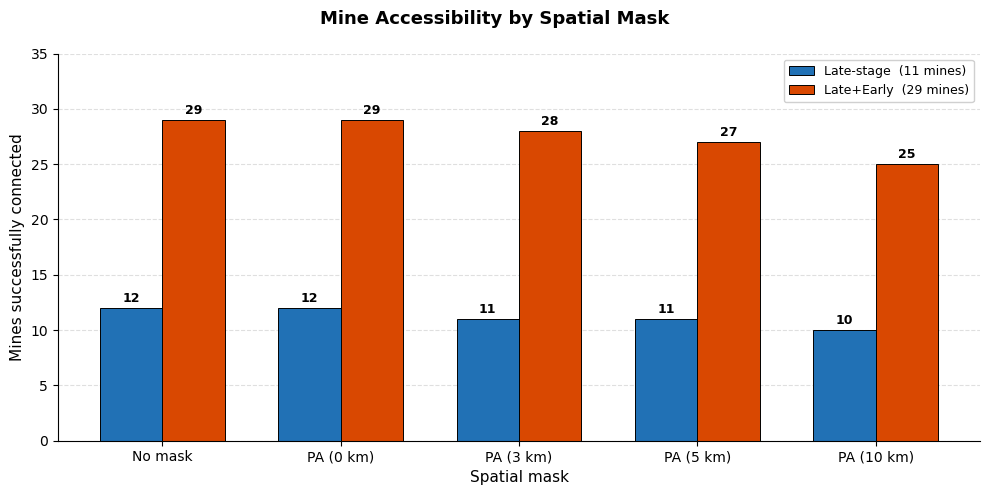

In [20]:
# n_mines_accessible depends only on mask — take first value per mining x mask
acc = (
    all_df.groupby(['mining', 'mask'])['n_mines_accessible']
    .first()
    .reset_index()
)

x = np.arange(len(MASK_ORDER))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Mine Accessibility by Spatial Mask', fontsize=13, fontweight='bold')

for i, mining in enumerate(MINING_ORDER):
    sub    = acc[acc['mining'] == mining].set_index('mask').reindex(MASK_ORDER)
    offset = (i - 0.5) * w
    bars   = ax.bar(x + offset, sub['n_mines_accessible'], w,
                    color=MINING_COLORS[mining], edgecolor='black', linewidth=0.7,
                    label=MINING_LABELS[mining])
    for bar, val in zip(bars, sub['n_mines_accessible']):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER], fontsize=10)
ax.set_ylabel('Mines successfully connected', fontsize=11)
ax.set_xlabel('Spatial mask', fontsize=11)
ax.set_ylim(0, 35)
ax.legend(fontsize=9, frameon=True, framealpha=0.92)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig0_mine_accessibility.png', dpi=150, bbox_inches='tight')
plt.show()

<p style="color: #1565c0; font-style: italic;">Add notes</p>

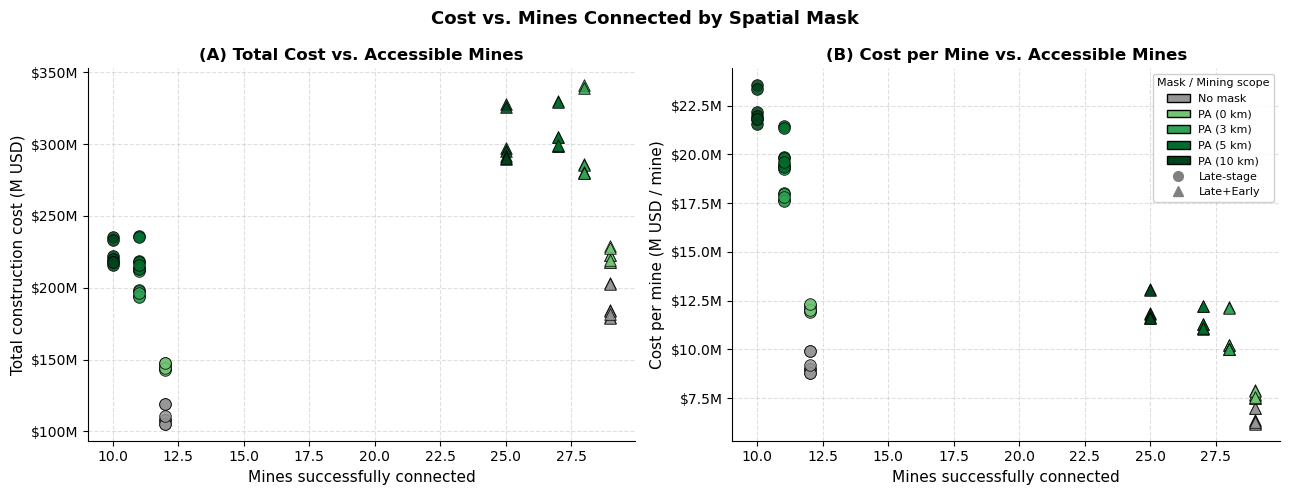

In [21]:
MASK_COLORS_RAMP = {
    'no_mask':                  '#969696',
    'protected_areas':          '#74c476',
    'protected_areas_buf3km':   '#31a354',
    'protected_areas_buf5km':   '#006d2c',
    'protected_areas_buf10km':  '#00441b',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Cost vs. Mines Connected by Spatial Mask',
             fontsize=13, fontweight='bold')

for _, row in all_df.iterrows():
    mc = MASK_COLORS_RAMP[row['mask']]
    mk = 'o' if row['mining'] == 'late_stage' else '^'
    kw = dict(s=70, color=mc, marker=mk, edgecolors='black',
              linewidth=0.6, alpha=0.88, zorder=5)
    ax1.scatter(row['n_mines_accessible'], row['total_cost_musd'],    **kw)
    ax2.scatter(row['n_mines_accessible'], row['cost_per_mine_musd'], **kw)

mask_handles = [
    mpatches.Patch(facecolor=MASK_COLORS_RAMP[m], edgecolor='black', label=MASK_LABELS[m])
    for m in MASK_ORDER
]
mining_handles = [
    mlines.Line2D([], [], marker='o', color='gray', linestyle='None',
                  markersize=7, label='Late-stage'),
    mlines.Line2D([], [], marker='^', color='gray', linestyle='None',
                  markersize=7, label='Late+Early'),
]

for ax in (ax1, ax2):
    ax.set_xlabel('Mines successfully connected', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)

ax1.set_ylabel('Total construction cost (M USD)', fontsize=11)
ax1.set_title('(A) Total Cost vs. Accessible Mines', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))

ax2.set_ylabel('Cost per mine (M USD / mine)', fontsize=11)
ax2.set_title('(B) Cost per Mine vs. Accessible Mines', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.1f}M'))
ax2.legend(handles=mask_handles + mining_handles, loc='best',
           fontsize=8, frameon=True, framealpha=0.92,
           title='Mask / Mining scope', title_fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig0c_cost_vs_mines_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

## 1. Construction Cost

Total and per-mine construction costs across all friction layers and spatial masks.
Per-mine normalization allows direct comparison between mining scopes (11 vs. 29 mines).

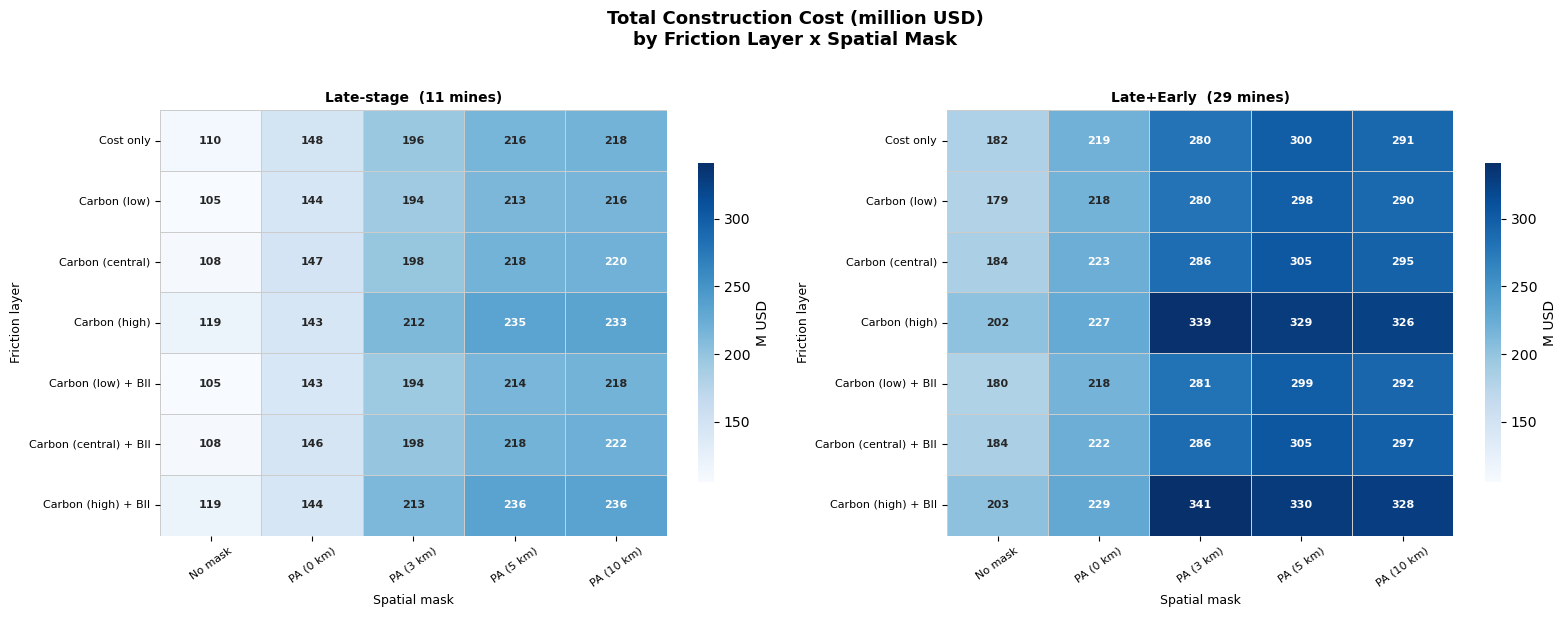

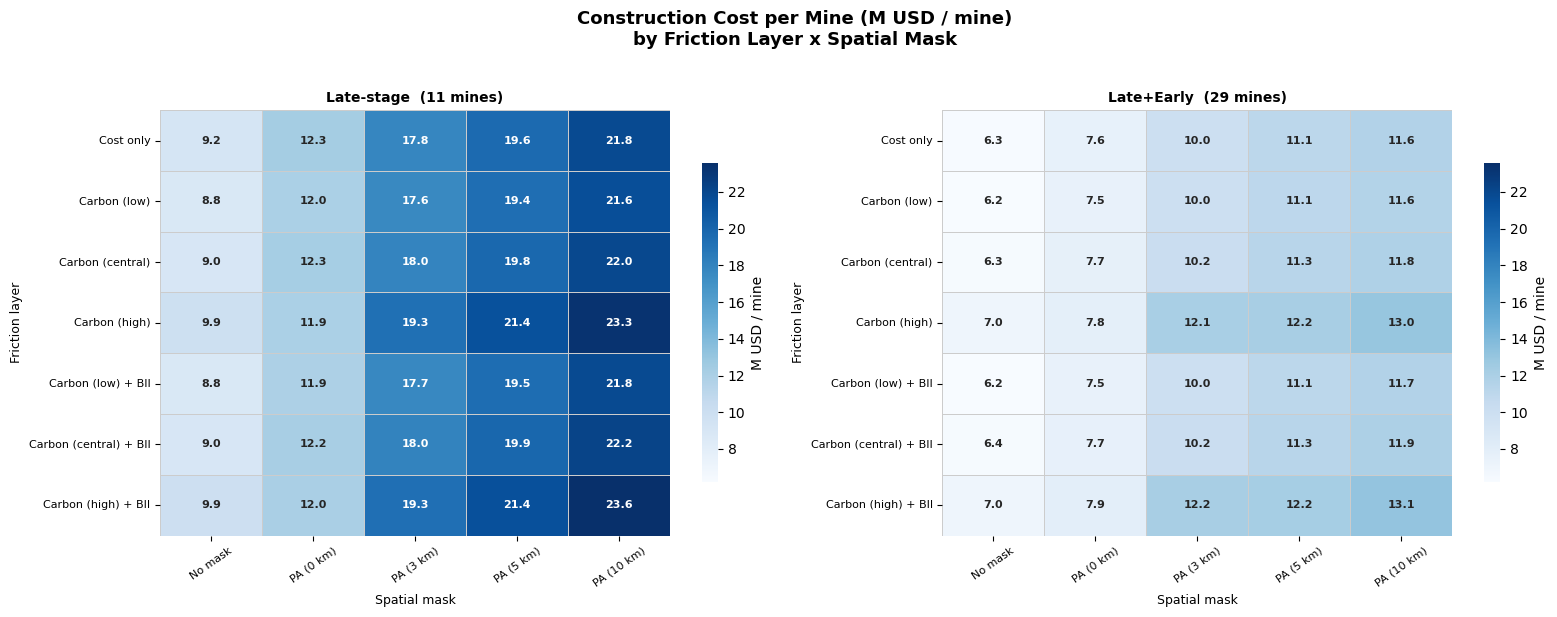

In [22]:
# ── Total cost ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Total Construction Cost (million USD)\nby Friction Layer x Spatial Mask',
             fontsize=13, fontweight='bold', y=1.02)
hm_pair(axes, all_df, 'total_cost_musd', suptitle='',
        cmap='Blues', fmt='.0f', cbar_label='M USD', shared_scale=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1a_cost_total_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-mine cost (normalized) ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Construction Cost per Mine (M USD / mine)\nby Friction Layer x Spatial Mask',
             fontsize=13, fontweight='bold', y=1.02)
hm_pair(axes, all_df, 'cost_per_mine_musd', suptitle='',
        cmap='Blues', fmt='.1f', cbar_label='M USD / mine', shared_scale=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1b_cost_per_mine_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

<p style="color: #1565c0; font-style: italic;">Add notes</p>

## 2. Deforestation Risk

Expected forest cleared (ha) derived from the Damania et al. (2018) road-deforestation decay function
(good road quality, 0–10 km corridor). Total and per-mine deforestation shown.

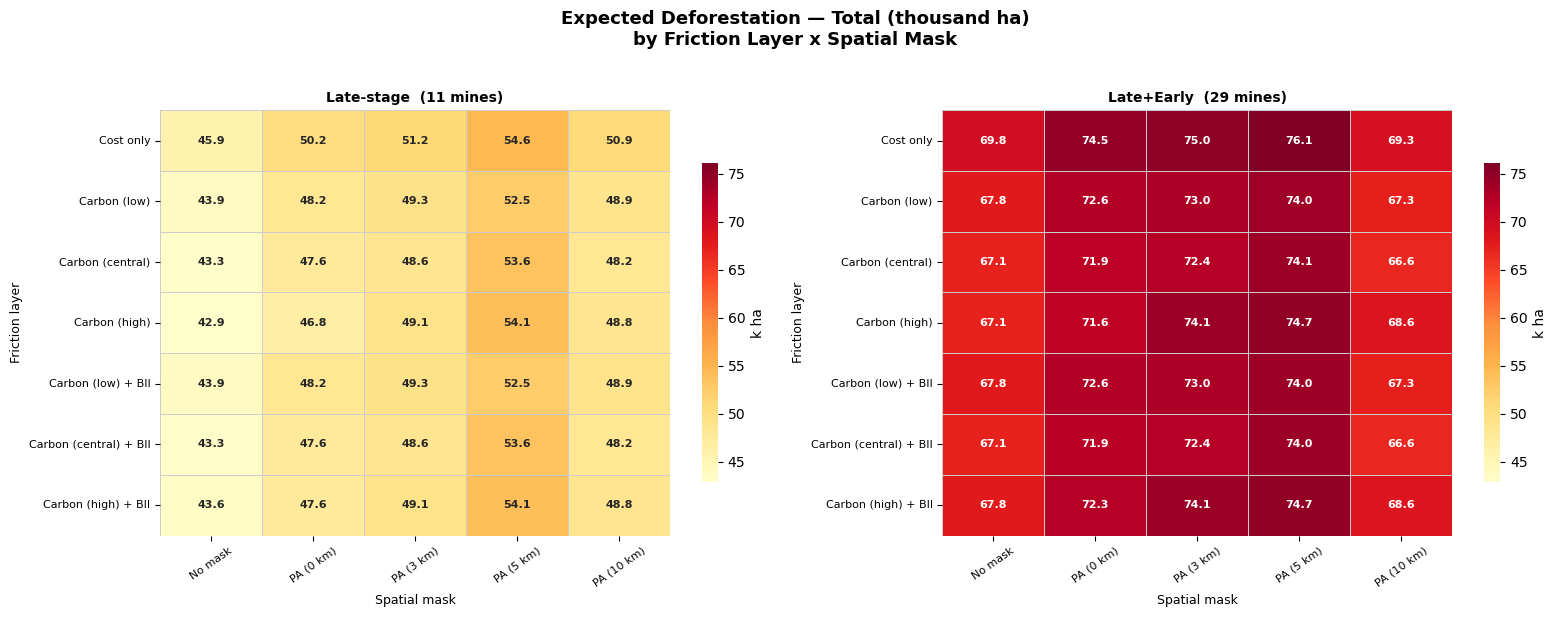

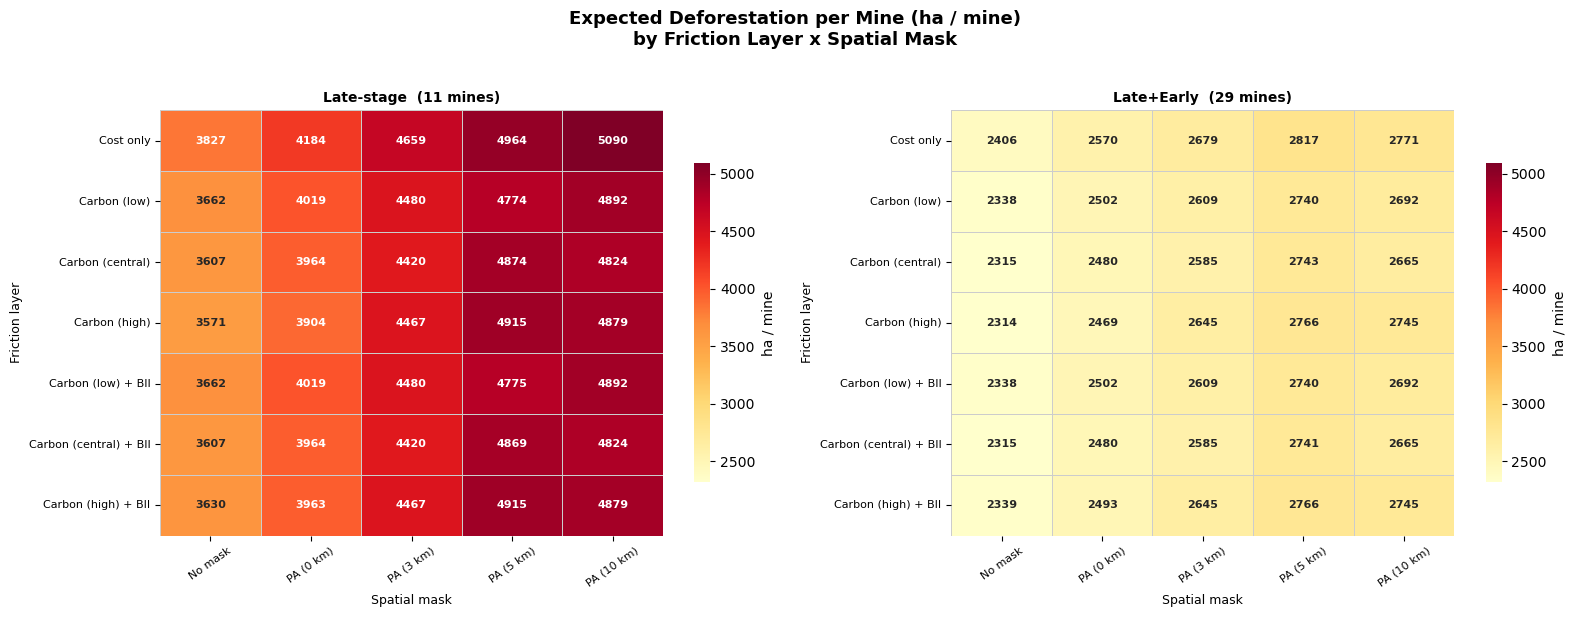

In [23]:
# ── Total deforestation ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Expected Deforestation — Total (thousand ha)\nby Friction Layer x Spatial Mask',
             fontsize=13, fontweight='bold', y=1.02)
hm_pair(axes, all_df, 'defor_action_kha', suptitle='',
        cmap='YlOrRd', fmt='.1f', cbar_label='k ha', shared_scale=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2a_defor_total_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-mine deforestation (normalized) ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Expected Deforestation per Mine (ha / mine)\nby Friction Layer x Spatial Mask',
             fontsize=13, fontweight='bold', y=1.02)
hm_pair(axes, all_df, 'defor_per_mine_ha', suptitle='',
        cmap='YlOrRd', fmt='.0f', cbar_label='ha / mine', shared_scale=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2b_defor_per_mine_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

<p style="color: #1565c0; font-style: italic;">Add notes</p>

## 3. Forest Fragmentation

Change in fragmentation index and patch count (action minus baseline) per admin2 department.
Positive delta = more fragmented relative to baseline; negative = patches merged or reduced.

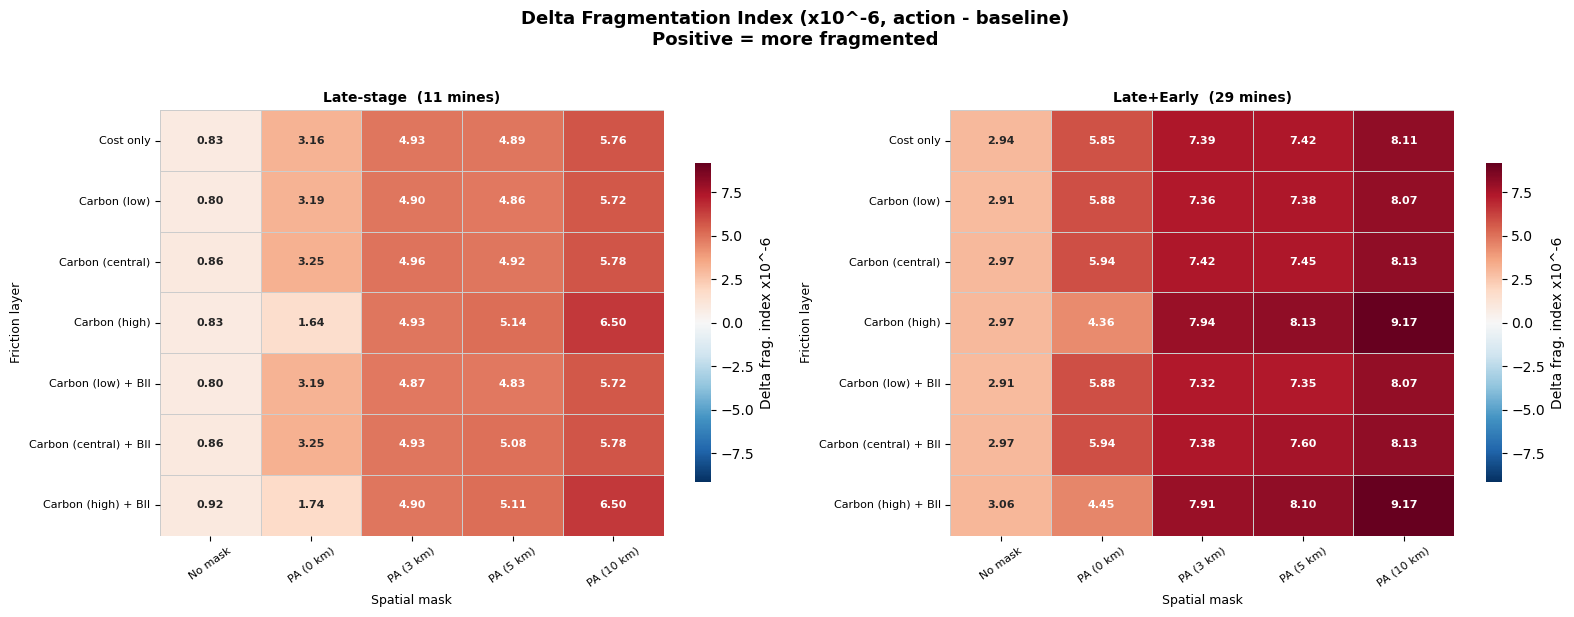

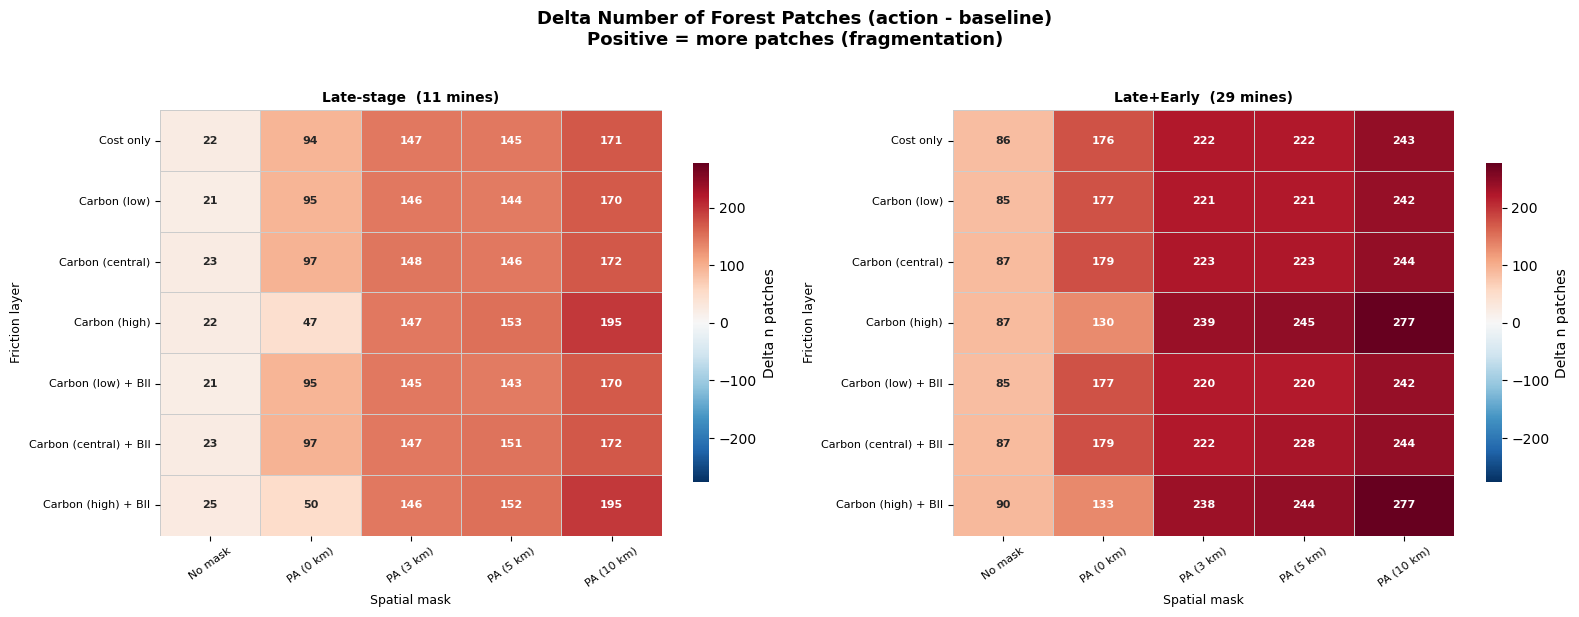

In [24]:
# ── Delta fragmentation index ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Delta Fragmentation Index (x10^-6, action - baseline)\nPositive = more fragmented',
             fontsize=13, fontweight='bold', y=1.02)
hm_pair(axes, all_df, 'delta_fi_e6', suptitle='',
        cmap='RdBu_r', fmt='.2f', cbar_label='Delta frag. index x10^-6',
        diverging=True, shared_scale=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3a_frag_index_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Delta patch count ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Delta Number of Forest Patches (action - baseline)\nPositive = more patches (fragmentation)',
             fontsize=13, fontweight='bold', y=1.02)
hm_pair(axes, all_df, 'frag_delta_n_patches', suptitle='',
        cmap='RdBu_r', fmt='.0f', cbar_label='Delta n patches',
        diverging=True, shared_scale=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3b_frag_patches_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

<p style="color: #1565c0; font-style: italic;">Add notes</p>

## 4. Cost–Environment Trade-offs

All 70 scenarios in cost–environment space. Color encodes friction layer; marker shape encodes
mining scope (circle = late-stage, triangle = late+early).

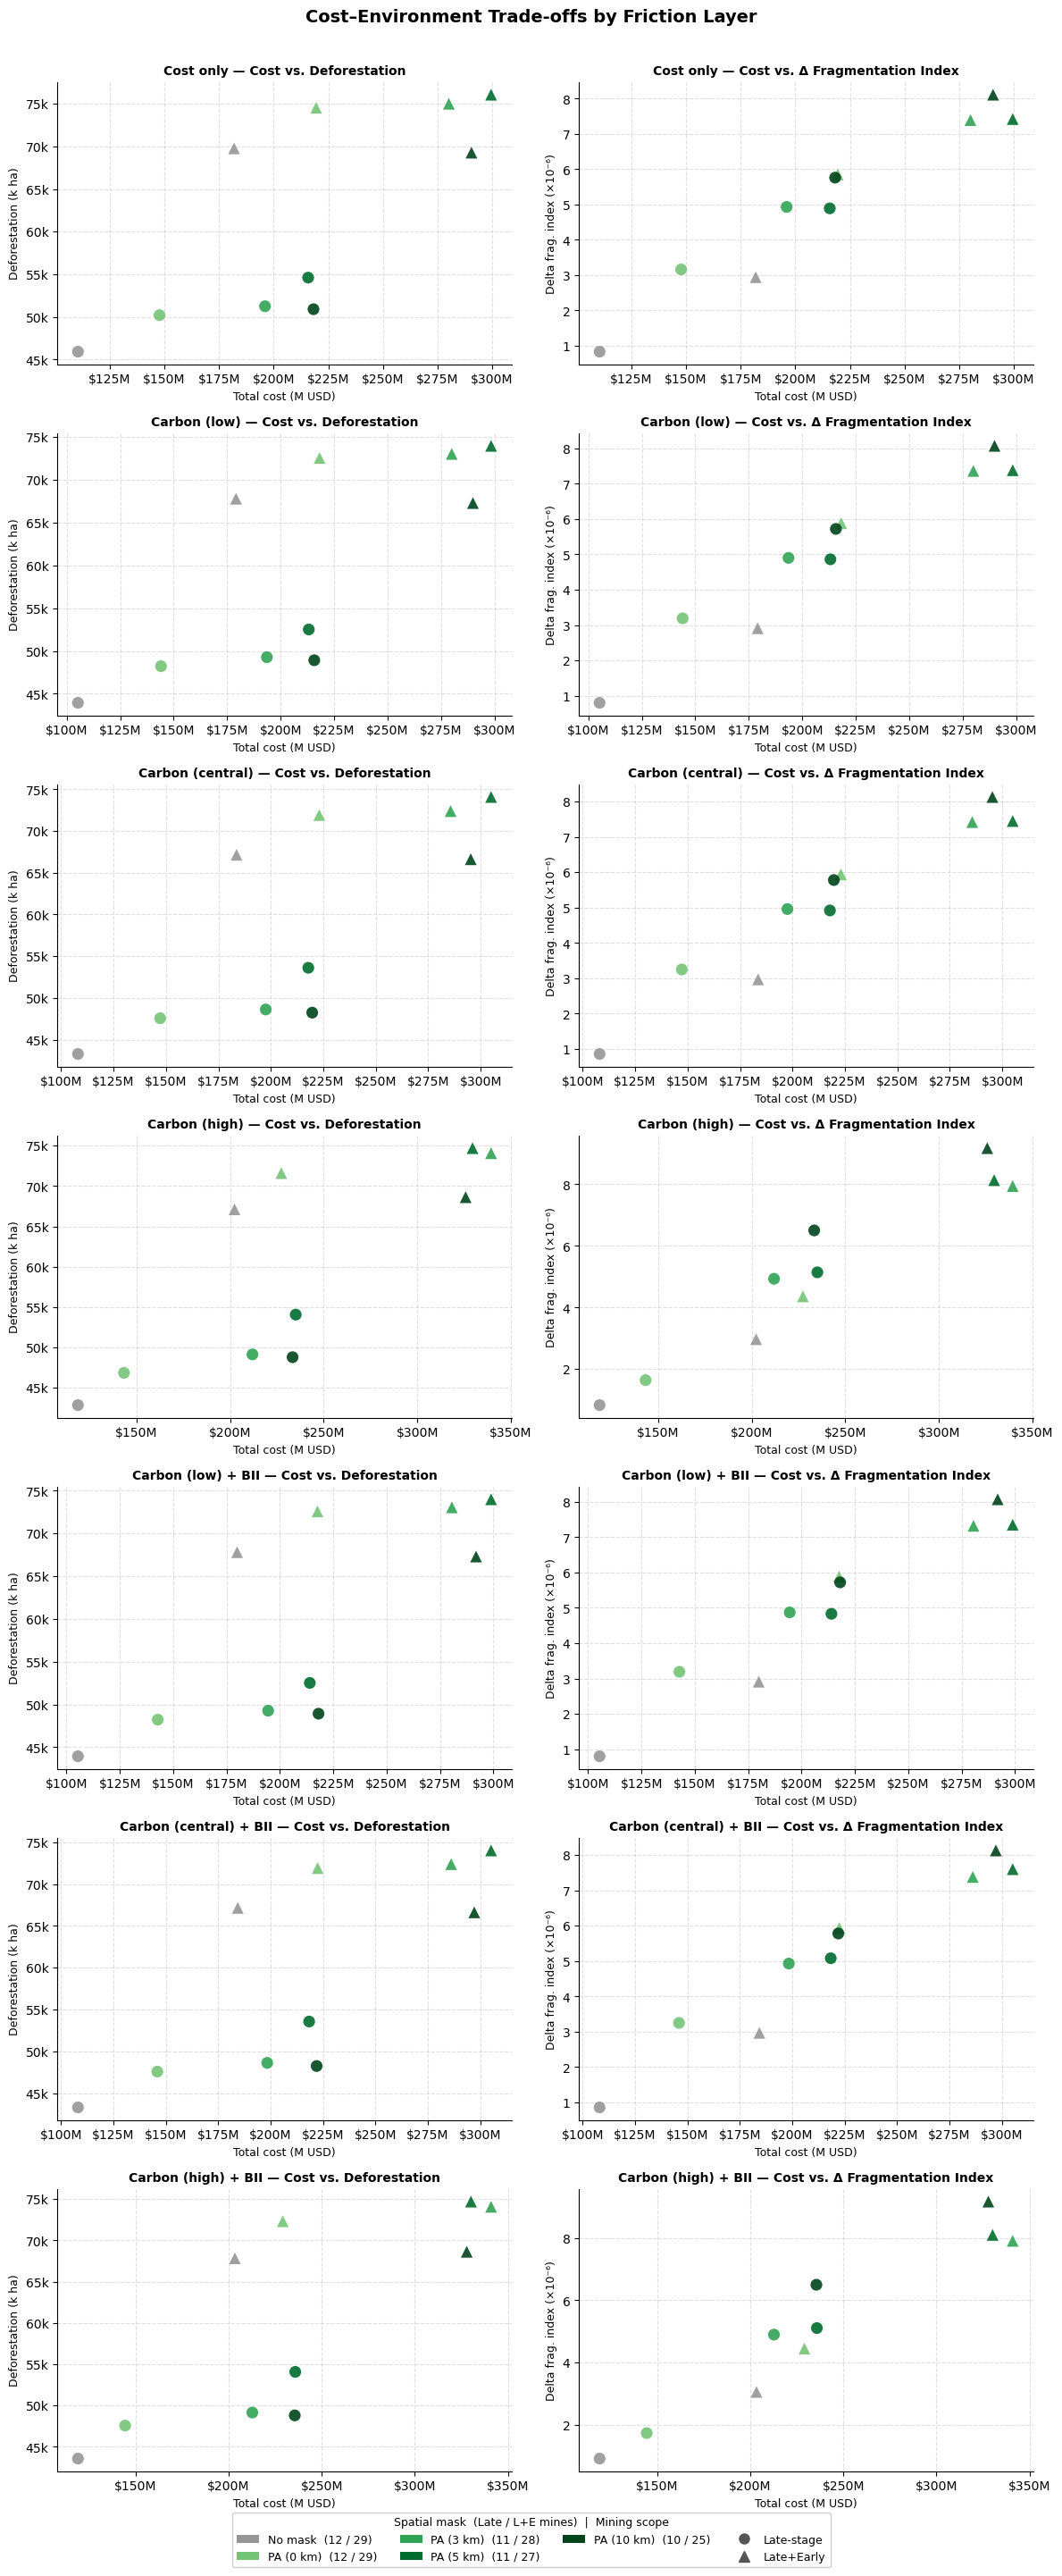

In [25]:
MASK_COLORS_SCATTER = {
    'no_mask':                  '#969696',
    'protected_areas':          '#74c476',
    'protected_areas_buf3km':   '#31a354',
    'protected_areas_buf5km':   '#006d2c',
    'protected_areas_buf10km':  '#00441b',
}

mine_counts = {}
for mask in MASK_ORDER:
    mine_counts[mask] = {}
    for mining in MINING_ORDER:
        sub = all_df[(all_df['mask'] == mask) & (all_df['mining'] == mining)]
        mine_counts[mask][mining] = int(sub['n_mines_accessible'].iloc[0]) if not sub.empty else '?'

fig, axes = plt.subplots(7, 2, figsize=(12, 28))
fig.suptitle('Cost–Environment Trade-offs by Friction Layer',
             fontsize=14, fontweight='bold', y=1.005)

for row_i, friction in enumerate(FRICTION_ORDER):
    ax1, ax2 = axes[row_i]
    sub = all_df[all_df['friction'] == friction]

    for _, r in sub.iterrows():
        mc = MASK_COLORS_SCATTER[r['mask']]
        mk = 'o' if r['mining'] == 'late_stage' else '^'
        kw = dict(s=90, color=mc, marker=mk, edgecolors='none', alpha=0.9, zorder=5)
        ax1.scatter(r['total_cost_musd'], r['defor_action_kha'], **kw)
        ax2.scatter(r['total_cost_musd'], r['delta_fi_e6'],       **kw)

    for ax in (ax1, ax2):
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
        ax.set_xlabel('Total cost (M USD)', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_axisbelow(True)
        ax.xaxis.grid(True, linestyle='--', alpha=0.4)
        ax.yaxis.grid(True, linestyle='--', alpha=0.4)

    ax1.set_ylabel('Deforestation (k ha)', fontsize=9)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}k'))
    ax2.set_ylabel('Delta frag. index (×10⁻⁶)', fontsize=9)

    label = FRICTION_LABELS[friction]
    ax1.set_title(f'{label} — Cost vs. Deforestation',       fontweight='bold', fontsize=10)
    ax2.set_title(f'{label} — Cost vs. Δ Fragmentation Index', fontweight='bold', fontsize=10)

# ── Shared legend below all rows ──────────────────────────────────────────────
mask_handles = [
    mpatches.Patch(facecolor=MASK_COLORS_SCATTER[m], edgecolor='none',
                   label=f'{MASK_LABELS[m]}  ({mine_counts[m]["late_stage"]} / {mine_counts[m]["late_and_early_stage"]})')
    for m in MASK_ORDER
]
scope_handles = [
    mlines.Line2D([], [], marker='o', color='#555', linestyle='None',
                  markersize=8, label='Late-stage'),
    mlines.Line2D([], [], marker='^', color='#555', linestyle='None',
                  markersize=8, label='Late+Early'),
]
fig.legend(
    handles=mask_handles + [mpatches.Patch(visible=False, label='')] + scope_handles,
    loc='lower center', bbox_to_anchor=(0.5, -0.02),
    ncol=4, fontsize=9, frameon=True, framealpha=0.95,
    title='Spatial mask  (Late / L+E mines)  |  Mining scope',
    title_fontsize=9,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_tradeoff_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


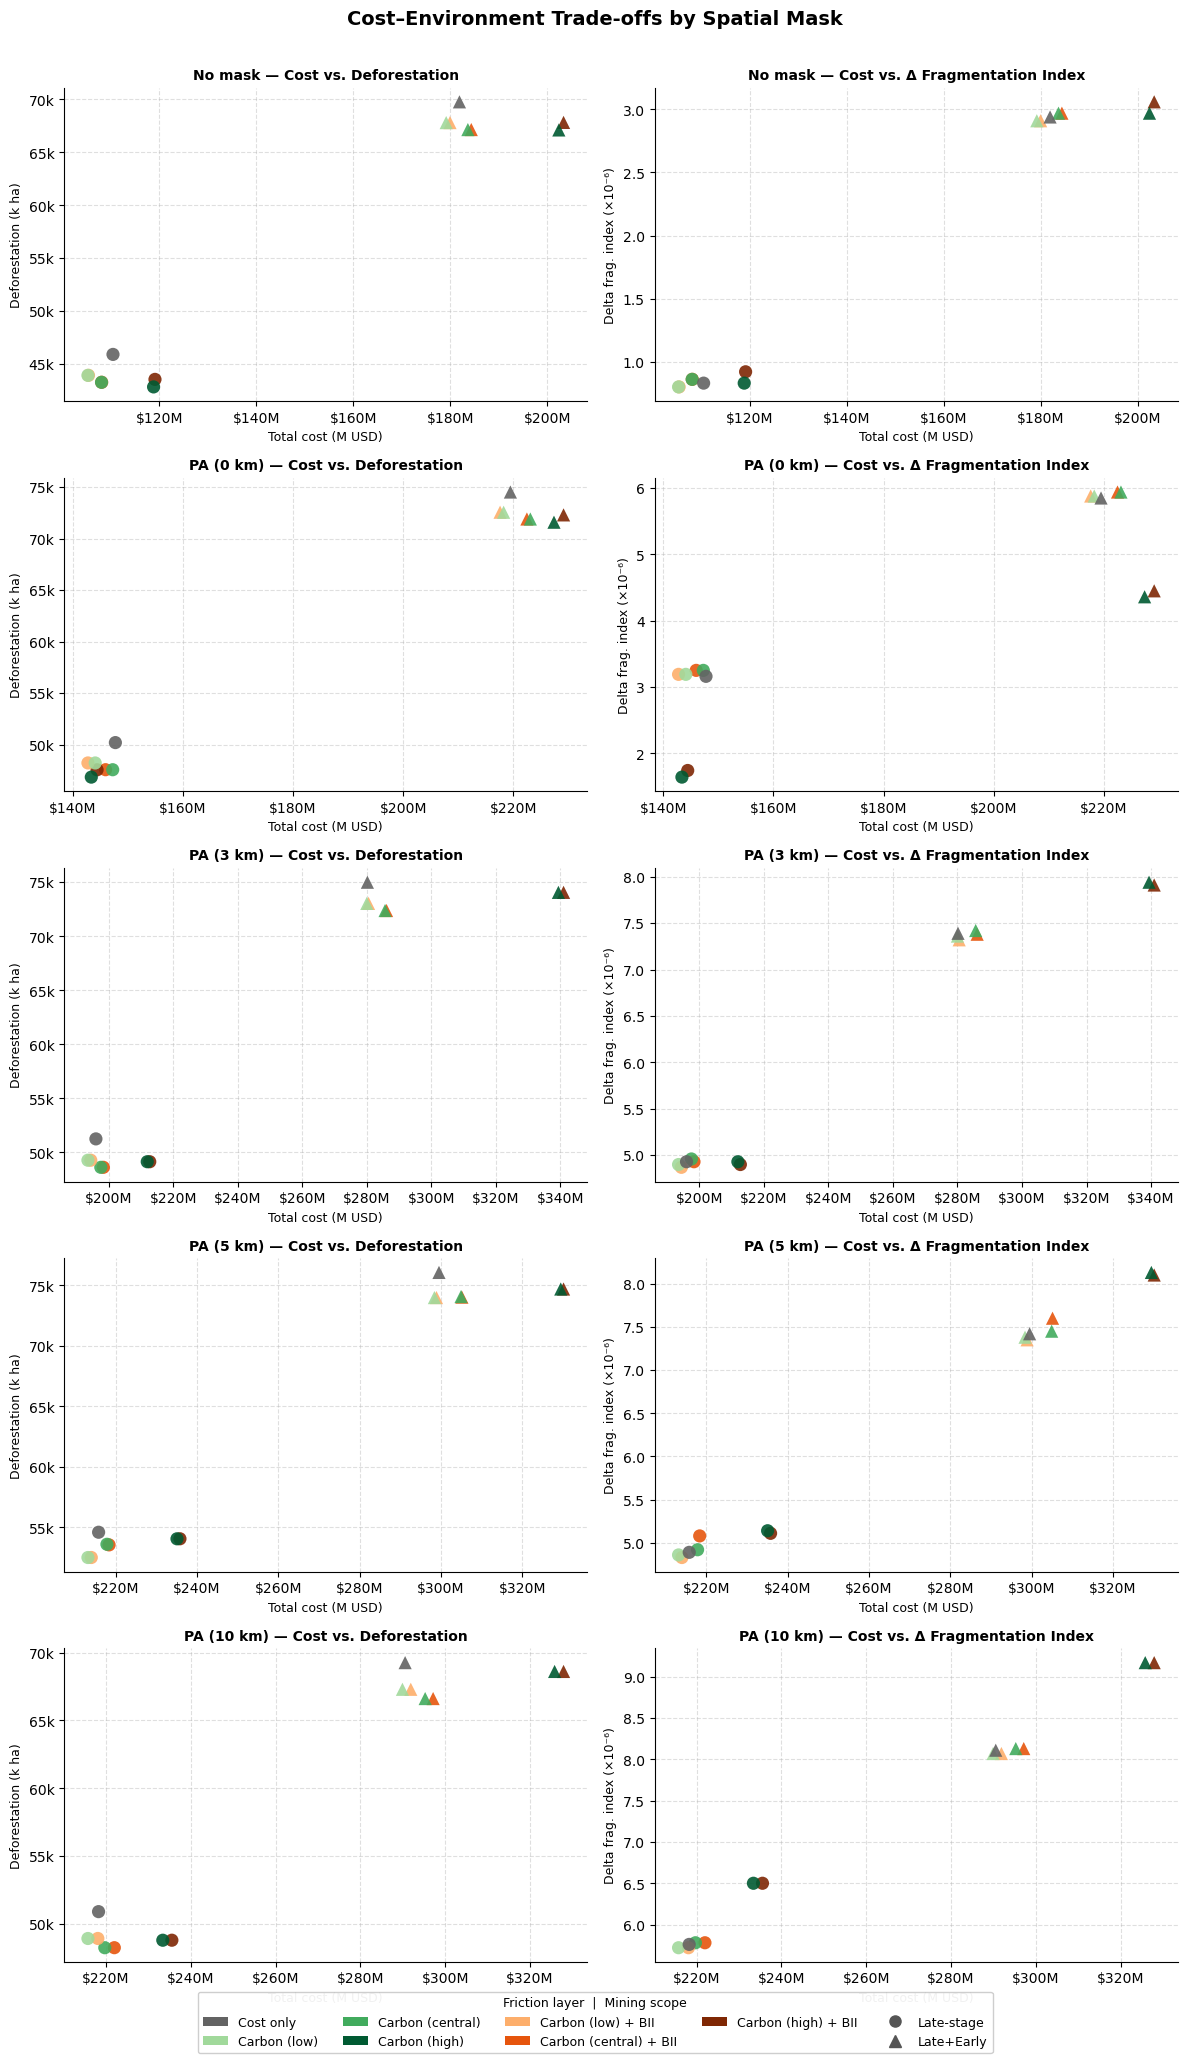

In [26]:
# Same trade-off scatter, flipped dimension: 5 rows = spatial masks, color = friction layer
fig, axes = plt.subplots(5, 2, figsize=(12, 20))
fig.suptitle('Cost–Environment Trade-offs by Spatial Mask',
             fontsize=14, fontweight='bold', y=1.005)

for row_i, mask in enumerate(MASK_ORDER):
    ax1, ax2 = axes[row_i]
    sub = all_df[all_df['mask'] == mask]

    for _, r in sub.iterrows():
        fc = FRICTION_COLORS[r['friction']]
        mk = 'o' if r['mining'] == 'late_stage' else '^'
        kw = dict(s=90, color=fc, marker=mk, edgecolors='none', alpha=0.9, zorder=5)
        ax1.scatter(r['total_cost_musd'], r['defor_action_kha'], **kw)
        ax2.scatter(r['total_cost_musd'], r['delta_fi_e6'],       **kw)

    for ax in (ax1, ax2):
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
        ax.set_xlabel('Total cost (M USD)', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_axisbelow(True)
        ax.xaxis.grid(True, linestyle='--', alpha=0.4)
        ax.yaxis.grid(True, linestyle='--', alpha=0.4)

    ax1.set_ylabel('Deforestation (k ha)', fontsize=9)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}k'))
    ax2.set_ylabel('Delta frag. index (×10⁻⁶)', fontsize=9)

    label = MASK_LABELS[mask]
    ax1.set_title(f'{label} — Cost vs. Deforestation',          fontweight='bold', fontsize=10)
    ax2.set_title(f'{label} — Cost vs. Δ Fragmentation Index',  fontweight='bold', fontsize=10)

# ── Shared legend below all rows ──────────────────────────────────────────────
fric_handles = [
    mpatches.Patch(facecolor=FRICTION_COLORS[f], edgecolor='none',
                   label=FRICTION_LABELS[f])
    for f in FRICTION_ORDER
]
scope_handles = [
    mlines.Line2D([], [], marker='o', color='#555', linestyle='None',
                  markersize=8, label='Late-stage'),
    mlines.Line2D([], [], marker='^', color='#555', linestyle='None',
                  markersize=8, label='Late+Early'),
]
fig.legend(
    handles=fric_handles + [mpatches.Patch(visible=False, label='')] + scope_handles,
    loc='lower center', bbox_to_anchor=(0.5, -0.02),
    ncol=5, fontsize=9, frameon=True, framealpha=0.95,
    title='Friction layer  |  Mining scope',
    title_fontsize=9,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4b_tradeoff_scatter_by_mask.png', dpi=150, bbox_inches='tight')
plt.show()


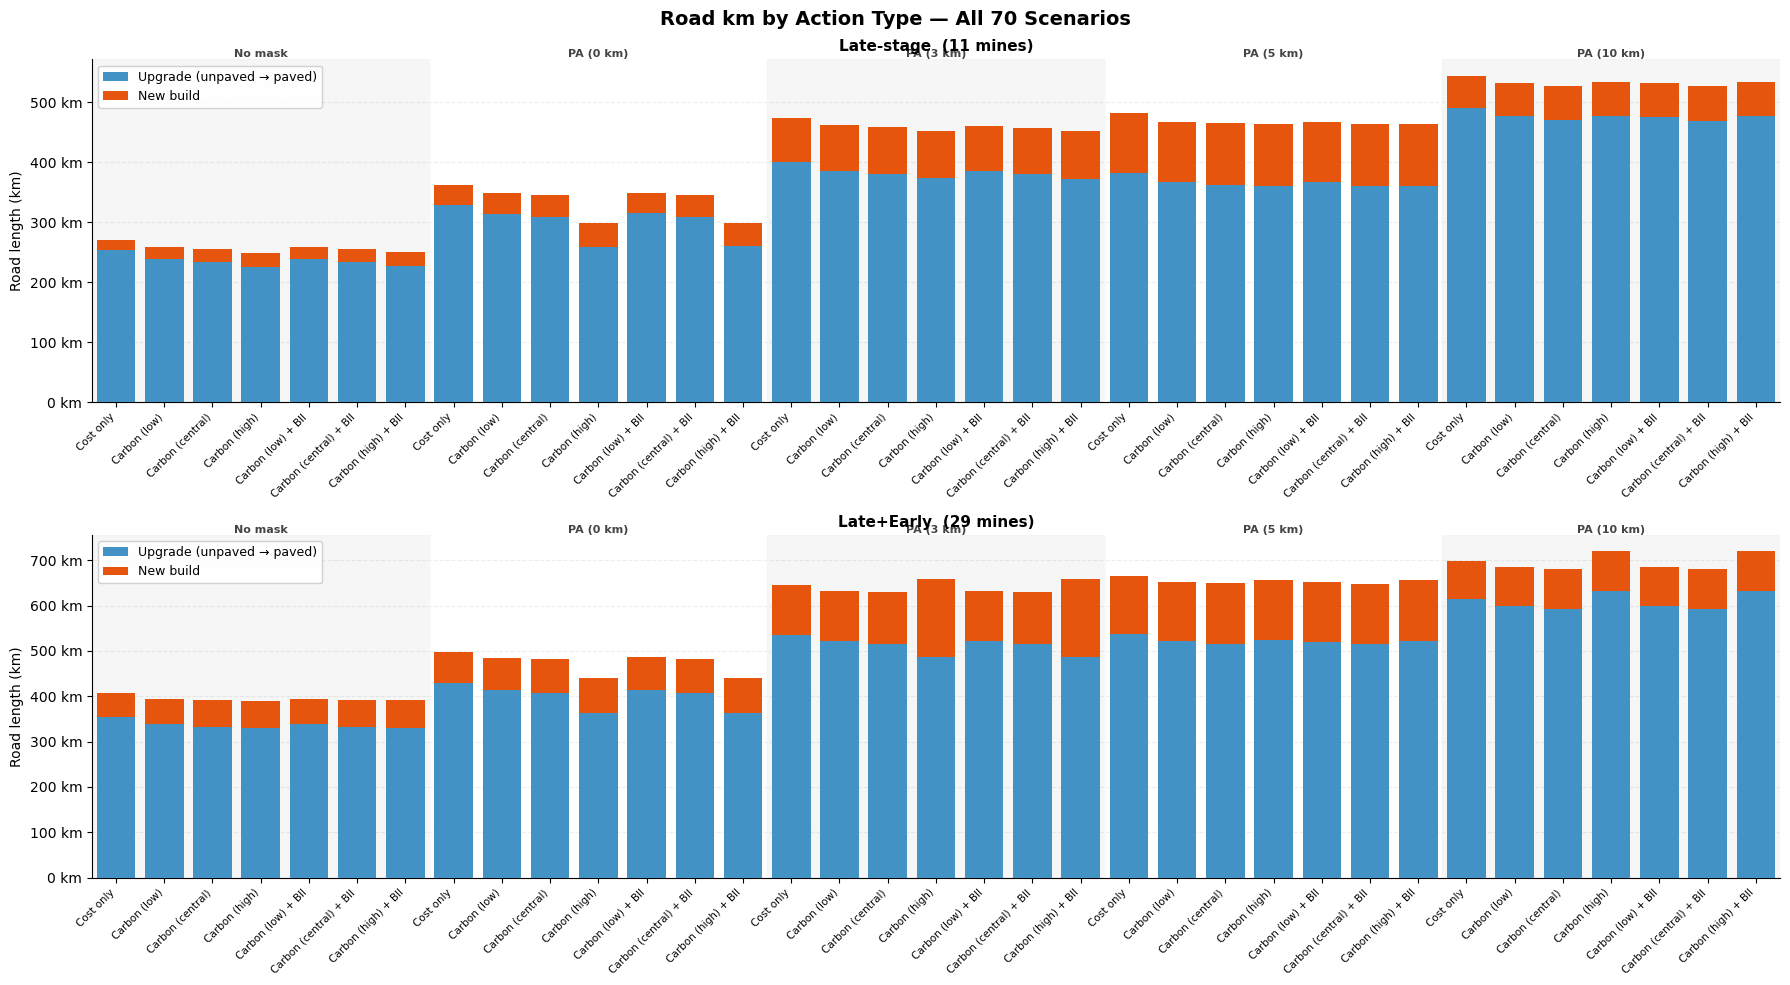

In [27]:
# Stacked bar: road km by action type for all 70 scenarios
# Grouped by mask (5 groups of 7 friction layers), split into 2 panels by mining scope

ACTION_COLORS = {
    'upgrade':   '#4292c6',   # blue  — unpaved → paved
    'new_build': '#e6550d',   # orange — new construction
}

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=False)
fig.suptitle('Road km by Action Type — All 70 Scenarios',
             fontsize=14, fontweight='bold')

for ax, mining in zip(axes, MINING_ORDER):
    sub = (
        all_df[all_df['mining'] == mining]
        .copy()
        .sort_values(['mask', 'friction'])   # group by mask, then friction within
        .reset_index(drop=True)
    )

    x      = np.arange(len(sub))
    bars_u = ax.bar(x, sub['unpaved_km'],     color=ACTION_COLORS['upgrade'],
                    label='Upgrade (unpaved → paved)', zorder=3)
    bars_b = ax.bar(x, sub['to_be_built_km'], bottom=sub['unpaved_km'],
                    color=ACTION_COLORS['new_build'],
                    label='New build', zorder=3)

    # ── Mask group separators and background bands ────────────────────────────
    group_starts = []
    for mask in MASK_ORDER:
        idx = sub[sub['mask'] == mask].index
        if len(idx):
            start = idx[0] - sub.index[0]   # position in the sorted array
            group_starts.append((start, mask))

    for gi, (start, mask) in enumerate(group_starts):
        end = group_starts[gi + 1][0] if gi + 1 < len(group_starts) else len(sub)
        color = '#f0f0f0' if gi % 2 == 0 else '#ffffff'
        ax.axvspan(start - 0.5, end - 0.5, color=color, zorder=1, alpha=0.6)
        ax.text((start + end) / 2 - 0.5, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1,
                MASK_LABELS[mask], ha='center', va='bottom', fontsize=8,
                fontweight='bold', color='#444')

    # ── Axis formatting ───────────────────────────────────────────────────────
    ax.set_xticks(x)
    ax.set_xticklabels(
        [FRICTION_LABELS[f] for f in sub['friction']],
        rotation=45, ha='right', fontsize=7.5,
    )
    ax.set_ylabel('Road length (km)', fontsize=10)
    ax.set_title(MINING_LABELS[mining], fontweight='bold', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f} km'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.set_xlim(-0.5, len(sub) - 0.5)
    ax.legend(loc='upper left', fontsize=9, frameon=True, framealpha=0.9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_road_action_stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()


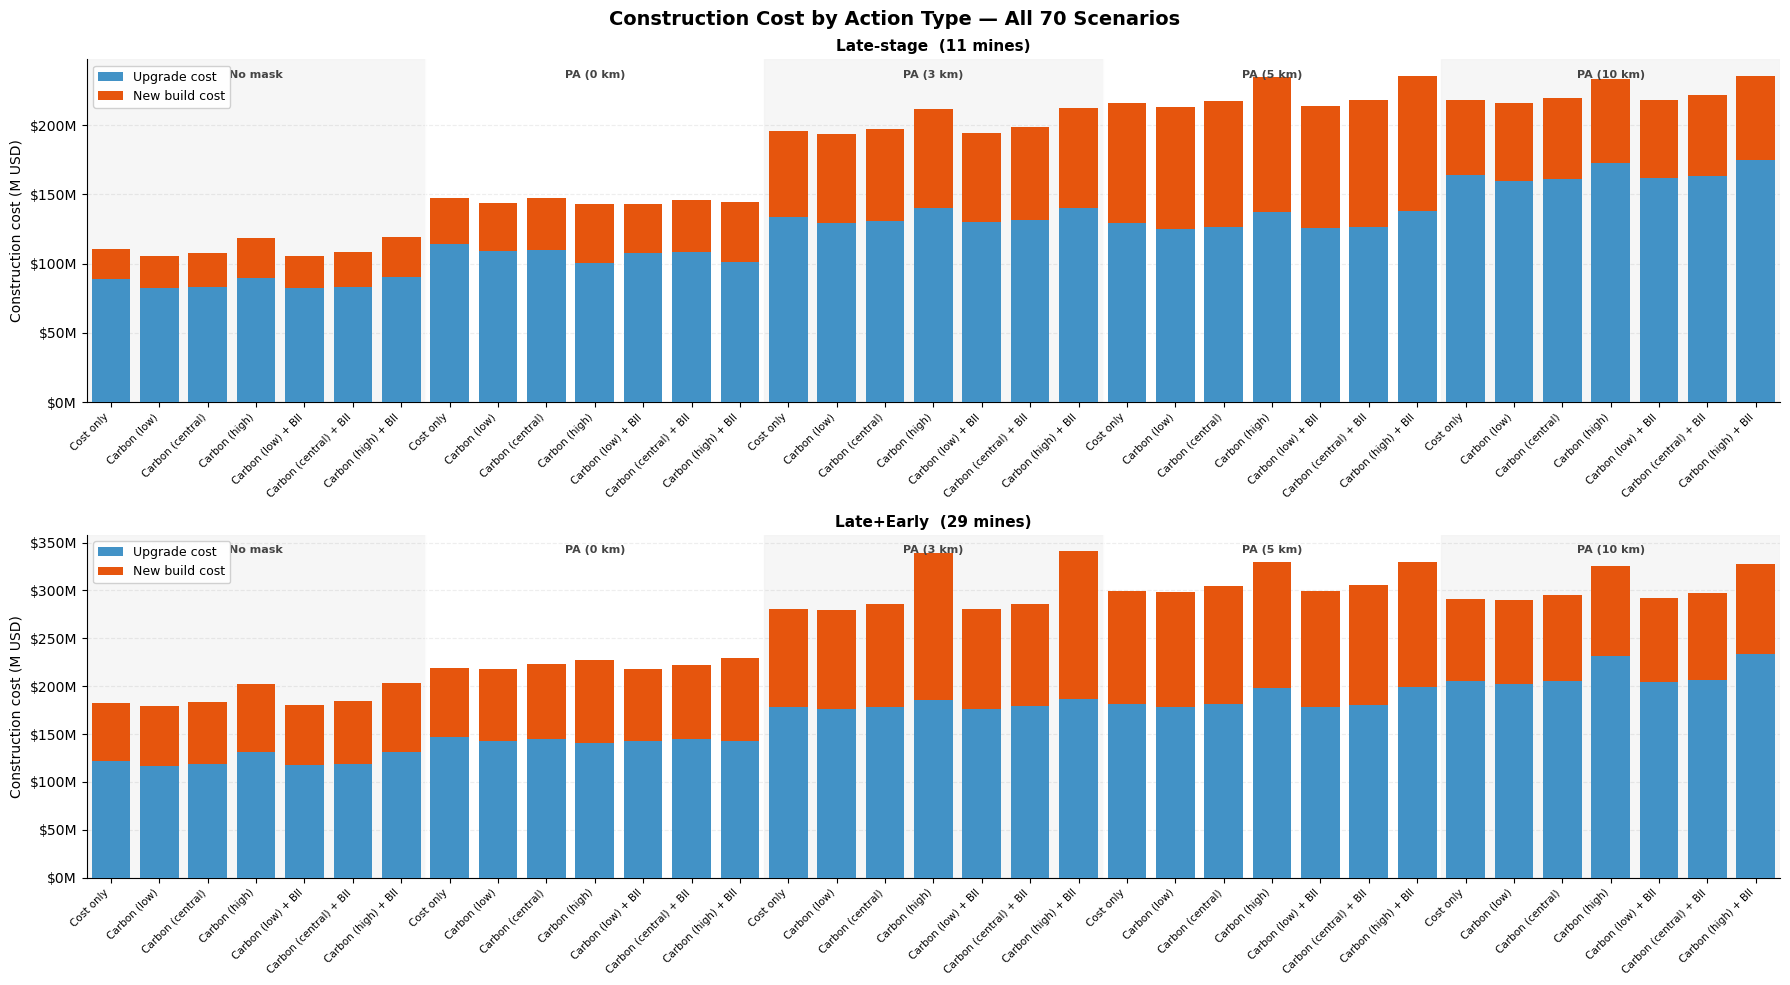

In [28]:
# Stacked bar: construction cost by action type for all 70 scenarios
all_df['upgrade_cost_musd']    = all_df['upgrade_cost_usd']    / 1e6
all_df['new_build_cost_musd']  = all_df['new_build_cost_usd']  / 1e6

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=False)
fig.suptitle('Construction Cost by Action Type — All 70 Scenarios',
             fontsize=14, fontweight='bold')

for ax, mining in zip(axes, MINING_ORDER):
    sub = (
        all_df[all_df['mining'] == mining]
        .copy()
        .sort_values(['mask', 'friction'])
        .reset_index(drop=True)
    )

    x = np.arange(len(sub))
    ax.bar(x, sub['upgrade_cost_musd'],   color=ACTION_COLORS['upgrade'],
           label='Upgrade cost', zorder=3)
    ax.bar(x, sub['new_build_cost_musd'], bottom=sub['upgrade_cost_musd'],
           color=ACTION_COLORS['new_build'],
           label='New build cost', zorder=3)

    # ── Mask group separators and background bands ────────────────────────────
    group_starts = []
    for mask in MASK_ORDER:
        idx = sub[sub['mask'] == mask].index
        if len(idx):
            group_starts.append((idx[0] - sub.index[0], mask))

    for gi, (start, mask) in enumerate(group_starts):
        end = group_starts[gi + 1][0] if gi + 1 < len(group_starts) else len(sub)
        ax.axvspan(start - 0.5, end - 0.5,
                   color='#f0f0f0' if gi % 2 == 0 else '#ffffff',
                   zorder=1, alpha=0.6)

    # Draw mask labels after bars so ylim is set
    ax.figure.canvas.draw()
    ymax = ax.get_ylim()[1]
    for gi, (start, mask) in enumerate(group_starts):
        end = group_starts[gi + 1][0] if gi + 1 < len(group_starts) else len(sub)
        ax.text((start + end) / 2 - 0.5, ymax * 0.97,
                MASK_LABELS[mask], ha='center', va='top',
                fontsize=8, fontweight='bold', color='#444')

    ax.set_xticks(x)
    ax.set_xticklabels(
        [FRICTION_LABELS[f] for f in sub['friction']],
        rotation=45, ha='right', fontsize=7.5,
    )
    ax.set_ylabel('Construction cost (M USD)', fontsize=10)
    ax.set_title(MINING_LABELS[mining], fontweight='bold', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.set_xlim(-0.5, len(sub) - 0.5)
    ax.legend(loc='upper left', fontsize=9, frameon=True, framealpha=0.9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_cost_action_stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()


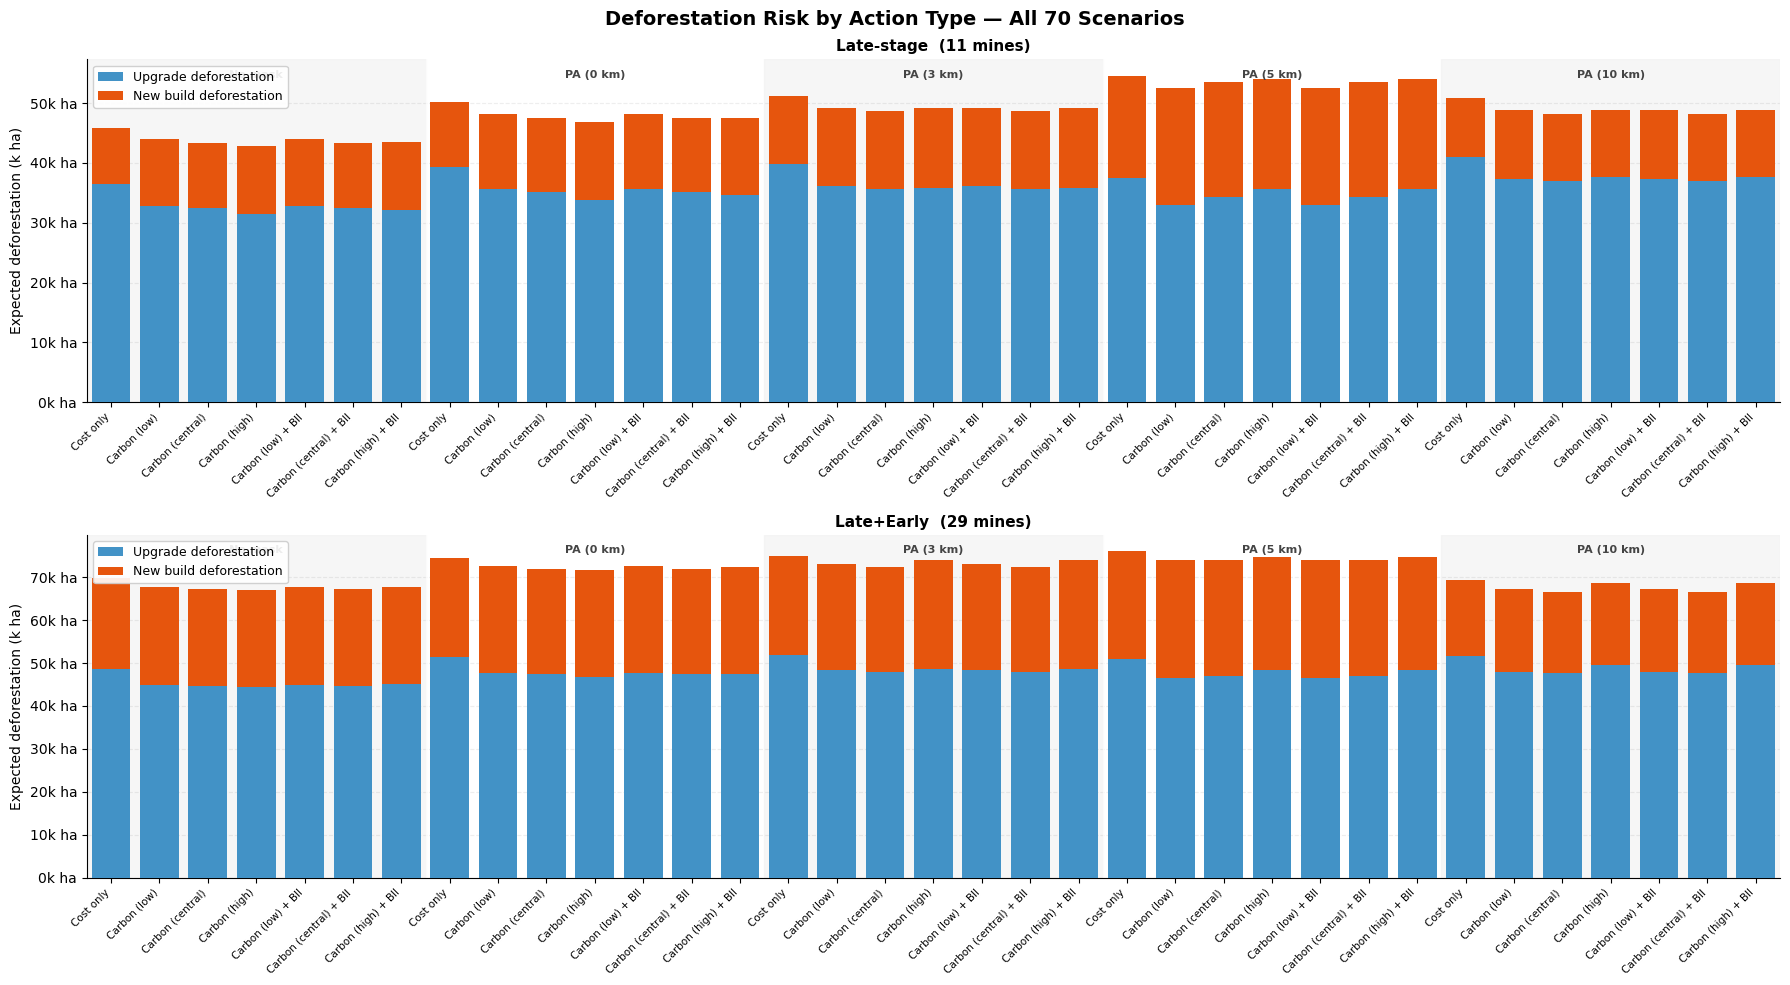

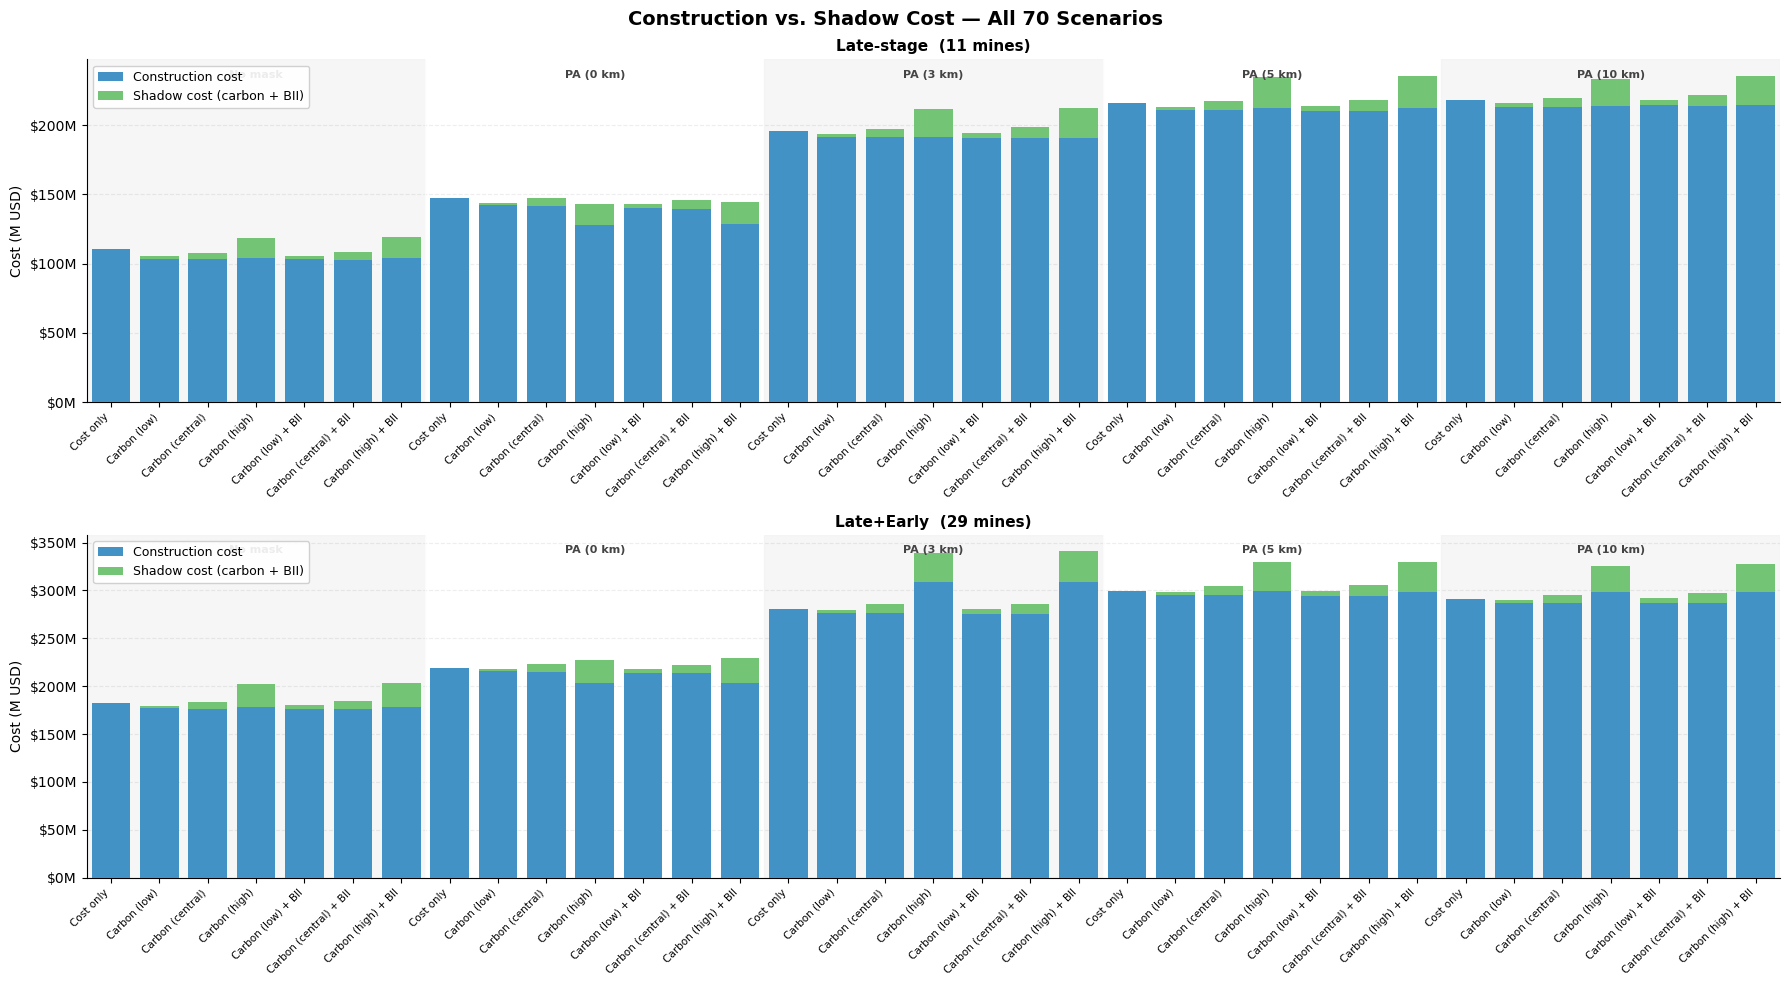

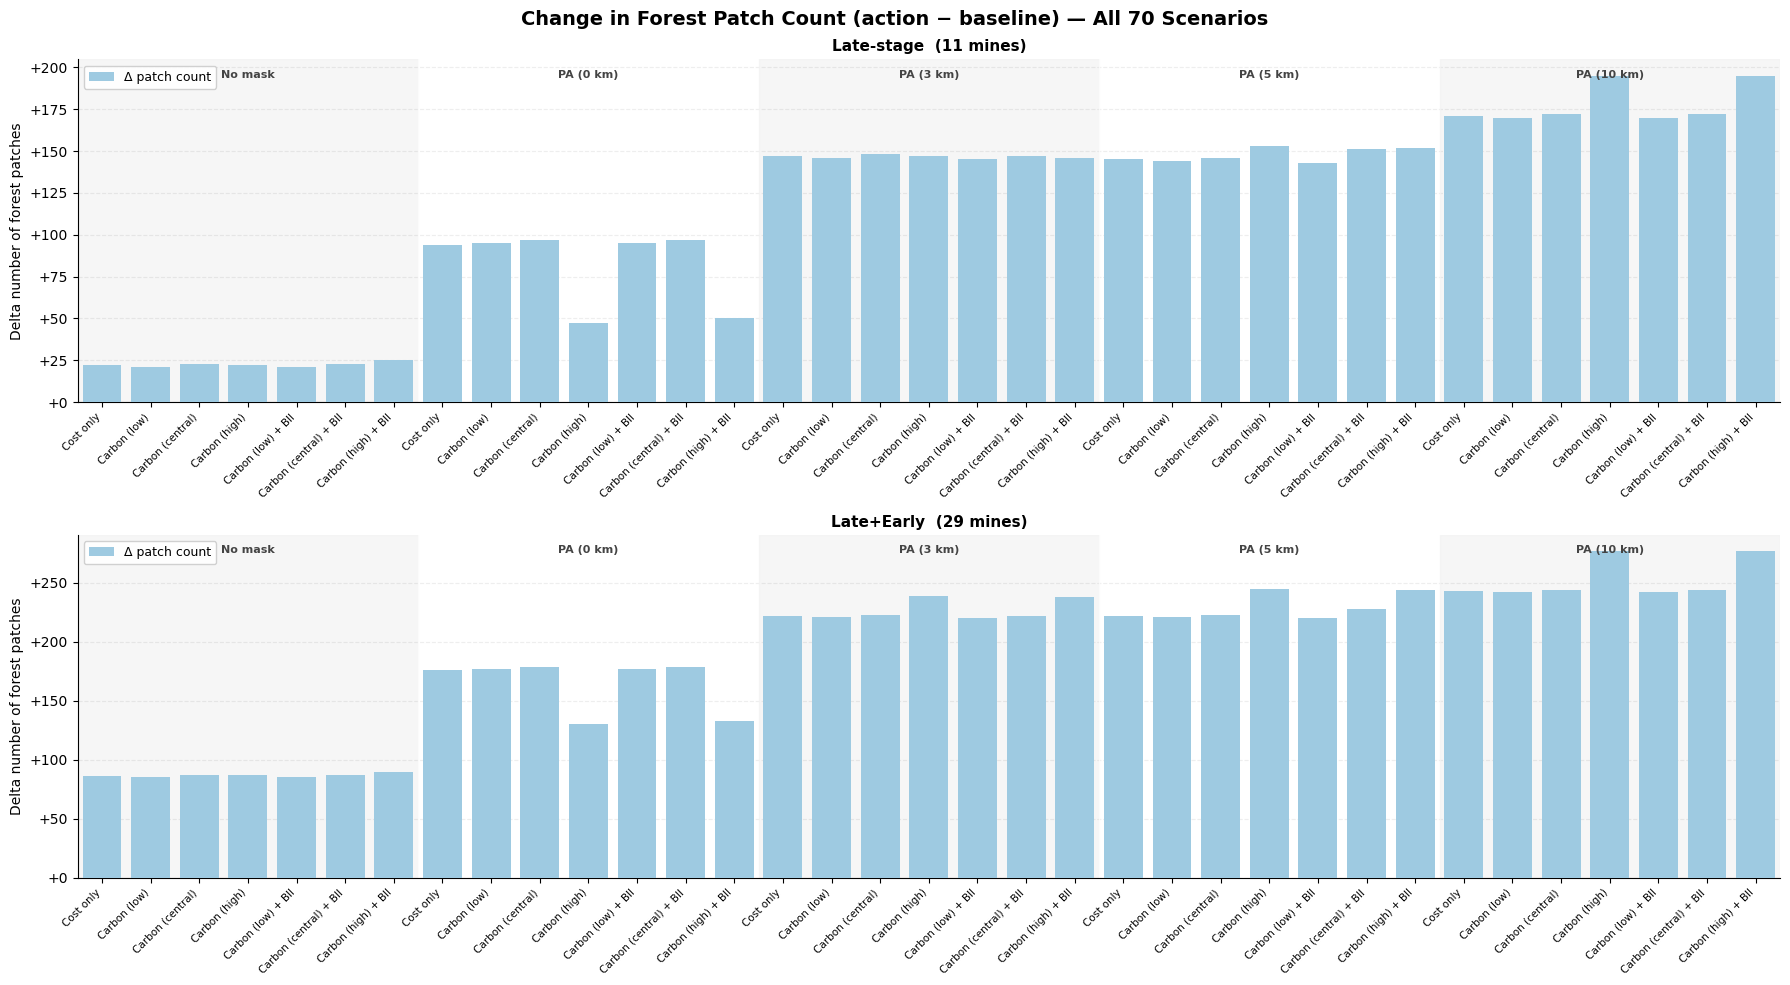

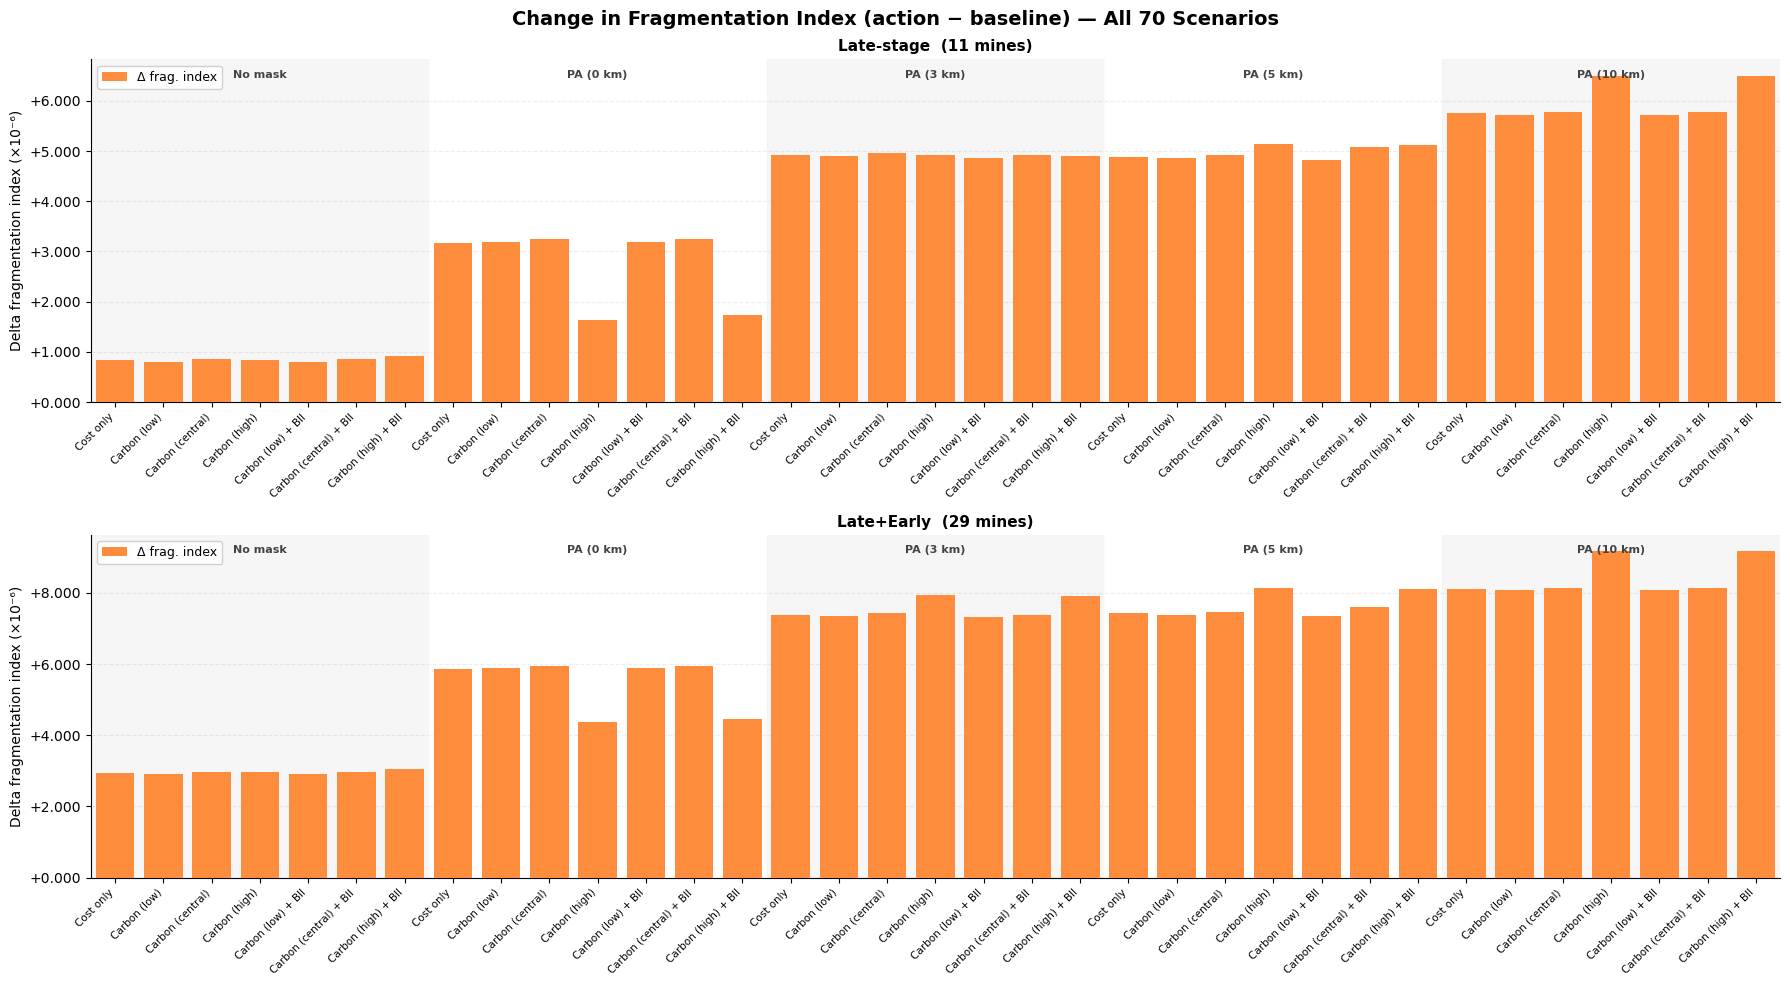

In [29]:
# ── Reusable helper ───────────────────────────────────────────────────────────
def stacked_action_bar(col_bottom, col_top=None,
                       label_bottom='', label_top='',
                       color_bottom=ACTION_COLORS['upgrade'],
                       color_top=ACTION_COLORS['new_build'],
                       ylabel='', suptitle='', fname=None,
                       fmt=None):
    """
    Two-panel (mining scope) stacked bar chart in the standard layout.
    col_top=None → single-color bar (col_bottom only).
    fmt: y-axis formatter string, e.g. '{x:.0f} km'.  None = plain numbers.
    """
    fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=False)
    fig.suptitle(suptitle, fontsize=14, fontweight='bold')

    for ax, mining in zip(axes, MINING_ORDER):
        sub = (
            all_df[all_df['mining'] == mining]
            .copy()
            .sort_values(['mask', 'friction'])
            .reset_index(drop=True)
        )
        x = np.arange(len(sub))

        bottom_vals = sub[col_bottom].fillna(0)
        ax.bar(x, bottom_vals, color=color_bottom, label=label_bottom, zorder=3)
        if col_top is not None:
            ax.bar(x, sub[col_top].fillna(0), bottom=bottom_vals,
                   color=color_top, label=label_top, zorder=3)

        # zero line for metrics that can go negative
        if bottom_vals.min() < 0 or (col_top is None and sub[col_bottom].min() < 0):
            ax.axhline(0, color='black', linewidth=0.8, zorder=4)

        # mask group bands
        group_starts = []
        for mask in MASK_ORDER:
            idx = sub[sub['mask'] == mask].index
            if len(idx):
                group_starts.append((idx[0] - sub.index[0], mask))

        for gi, (start, mask) in enumerate(group_starts):
            end = group_starts[gi + 1][0] if gi + 1 < len(group_starts) else len(sub)
            ax.axvspan(start - 0.5, end - 0.5,
                       color='#f0f0f0' if gi % 2 == 0 else '#ffffff',
                       zorder=1, alpha=0.6)

        # mask labels (drawn after bars so ylim is correct)
        fig.canvas.draw()
        ymin, ymax = ax.get_ylim()
        label_y = ymax - (ymax - ymin) * 0.03
        for gi, (start, mask) in enumerate(group_starts):
            end = group_starts[gi + 1][0] if gi + 1 < len(group_starts) else len(sub)
            ax.text((start + end) / 2 - 0.5, label_y,
                    MASK_LABELS[mask], ha='center', va='top',
                    fontsize=8, fontweight='bold', color='#444')

        ax.set_xticks(x)
        ax.set_xticklabels([FRICTION_LABELS[f] for f in sub['friction']],
                           rotation=45, ha='right', fontsize=7.5)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(MINING_LABELS[mining], fontweight='bold', fontsize=11)
        if fmt:
            ax.yaxis.set_major_formatter(
                mticker.FuncFormatter(lambda v, _, f=fmt: f.format(x=v)))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
        ax.set_xlim(-0.5, len(sub) - 0.5)
        if label_bottom:
            ax.legend(loc='upper left', fontsize=9, frameon=True, framealpha=0.9)

    plt.tight_layout()
    if fname:
        plt.savefig(FIGURES_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()


# ── Derived columns (add once) ────────────────────────────────────────────────
all_df['defor_upgrade_kha']      = all_df['defor_upgrade_ha']      / 1e3
all_df['defor_build_kha']        = all_df['defor_build_ha']        / 1e3
all_df['construction_cost_musd'] = all_df['construction_cost_usd'] / 1e6
all_df['shadow_cost_musd']       = all_df['shadow_cost_usd']       / 1e6

# ── 1. Deforestation by action type ──────────────────────────────────────────
stacked_action_bar(
    col_bottom='defor_upgrade_kha', col_top='defor_build_kha',
    label_bottom='Upgrade deforestation', label_top='New build deforestation',
    ylabel='Expected deforestation (k ha)',
    suptitle='Deforestation Risk by Action Type — All 70 Scenarios',
    fmt='{x:.0f}k ha', fname='fig_defor_action_stacked_bar.png',
)

# ── 2. Construction cost vs. shadow cost ──────────────────────────────────────
stacked_action_bar(
    col_bottom='construction_cost_musd', col_top='shadow_cost_musd',
    label_bottom='Construction cost', label_top='Shadow cost (carbon + BII)',
    color_bottom='#4292c6', color_top='#74c476',
    ylabel='Cost (M USD)',
    suptitle='Construction vs. Shadow Cost — All 70 Scenarios',
    fmt='${x:.0f}M', fname='fig_cost_construction_shadow_stacked_bar.png',
)

# ── 3. Delta forest patch count ───────────────────────────────────────────────
stacked_action_bar(
    col_bottom='frag_delta_n_patches',
    label_bottom='Δ patch count',
    color_bottom='#9ecae1',
    ylabel='Delta number of forest patches',
    suptitle='Change in Forest Patch Count (action − baseline) — All 70 Scenarios',
    fmt='{x:+.0f}', fname='fig_frag_delta_patches_bar.png',
)

# ── 4. Delta fragmentation index ──────────────────────────────────────────────
stacked_action_bar(
    col_bottom='delta_fi_e6',
    label_bottom='Δ frag. index',
    color_bottom='#fd8d3c',
    ylabel='Delta fragmentation index (×10⁻⁶)',
    suptitle='Change in Fragmentation Index (action − baseline) — All 70 Scenarios',
    fmt='{x:+.3f}', fname='fig_frag_delta_index_bar.png',
)


<p style="color: #1565c0; font-style: italic;">Add notes</p>

## 5. Protected Area Buffer Sensitivity

How does enlarging the protected area buffer affect route cost and deforestation?
Lines show mean across both mining scopes; one line per friction layer.

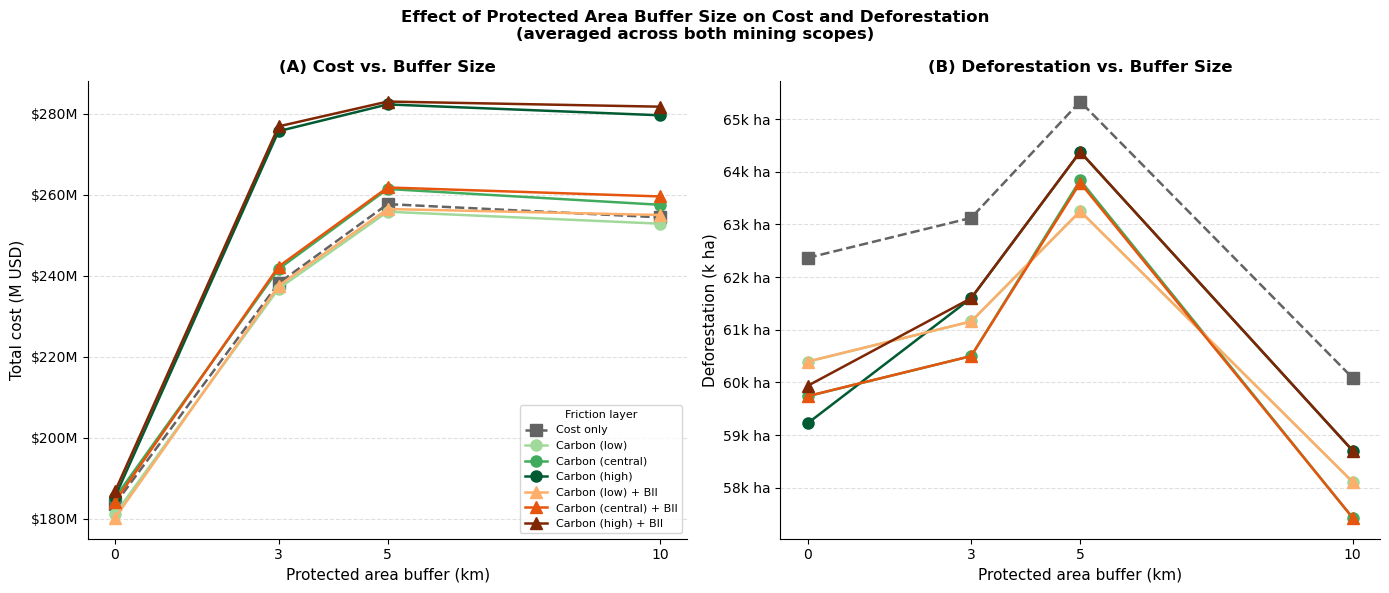

In [30]:
MASK_BUFFER_KM = {
    'protected_areas':           0,
    'protected_areas_buf3km':    3,
    'protected_areas_buf5km':    5,
    'protected_areas_buf10km':  10,
}

buf_df = all_df[all_df['mask'] != 'no_mask'].copy()
buf_df['buffer_km'] = buf_df['mask'].map(MASK_BUFFER_KM)

FRIC_LINE = {
    'construction_only':            ('#636363', 's', '--'),
    'carbon_low':                   ('#a1d99b', 'o', '-'),
    'carbon_central':               ('#41ab5d', 'o', '-'),
    'carbon_high':                  ('#005a32', 'o', '-'),
    'carbon_low__biodiversity':     ('#fdae6b', '^', '-'),
    'carbon_central__biodiversity': ('#e6550d', '^', '-'),
    'carbon_high__biodiversity':    ('#7f2704', '^', '-'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Effect of Protected Area Buffer Size on Cost and Deforestation\n'
             '(averaged across both mining scopes)',
             fontsize=12, fontweight='bold')

for friction in FRICTION_ORDER:
    color, marker, ls = FRIC_LINE[friction]
    label = FRICTION_LABELS[friction]
    sub = buf_df[buf_df['friction'] == friction]
    agg = (
        sub.groupby('buffer_km')[['total_cost_musd', 'defor_action_kha']]
           .mean()
           .reset_index()
           .sort_values('buffer_km')
    )
    axes[0].plot(agg['buffer_km'], agg['total_cost_musd'],
                 marker=marker, color=color, linestyle=ls,
                 linewidth=1.8, markersize=8, label=label)
    axes[1].plot(agg['buffer_km'], agg['defor_action_kha'],
                 marker=marker, color=color, linestyle=ls,
                 linewidth=1.8, markersize=8, label=label)

axes[0].set_ylabel('Total cost (M USD)', fontsize=11)
axes[0].set_title('(A) Cost vs. Buffer Size', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
axes[0].legend(fontsize=8, frameon=True, title='Friction layer', title_fontsize=8)

axes[1].set_ylabel('Deforestation (k ha)', fontsize=11)
axes[1].set_title('(B) Deforestation vs. Buffer Size', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}k ha'))

for ax in axes:
    ax.set_xlabel('Protected area buffer (km)', fontsize=11)
    ax.set_xticks([0, 3, 5, 10])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_buffer_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

<p style="color: #1565c0; font-style: italic;">Add notes</p>

## 6. Biodiversity Layer Effect

Adding the biodiversity intactness index (BII) penalty to the friction surface changes route selection.
For each carbon price level (low / central / high), this compares the BII scenario against the
carbon-only baseline and shows the average change across all masks and mining scopes.

C:\Users\Move\AppData\Local\Temp\ipykernel_32236\2411145965.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bio_agg.index, rotation=15, ha='right', fontsize=9)
C:\Users\Move\AppData\Local\Temp\ipykernel_32236\2411145965.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bio_agg.index, rotation=15, ha='right', fontsize=9)
C:\Users\Move\AppData\Local\Temp\ipykernel_32236\2411145965.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bio_agg.index, rotation=15, ha='right', fontsize=9)


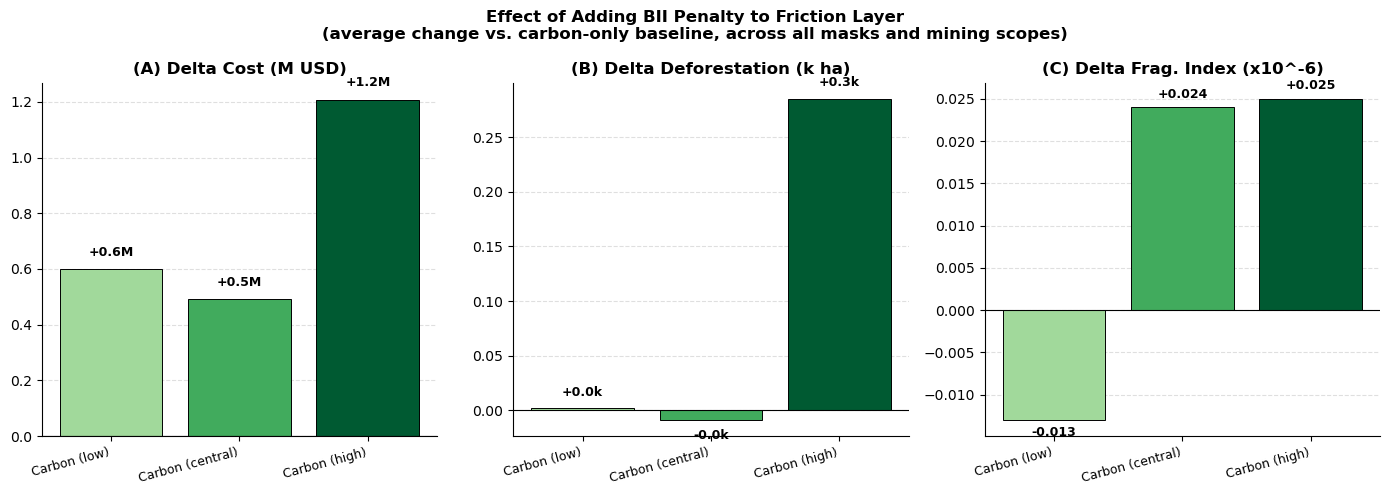

In [31]:
BIO_PAIRS = [
    ('carbon_low',     'carbon_low__biodiversity',     'Carbon (low)'),
    ('carbon_central', 'carbon_central__biodiversity', 'Carbon (central)'),
    ('carbon_high',    'carbon_high__biodiversity',    'Carbon (high)'),
]

records = []
for base_fric, bio_fric, label in BIO_PAIRS:
    for mining in MINING_ORDER:
        for mask in MASK_ORDER:
            base_row = all_df[
                (all_df['friction'] == base_fric) &
                (all_df['mining']   == mining) &
                (all_df['mask']     == mask)
            ]
            bio_row = all_df[
                (all_df['friction'] == bio_fric) &
                (all_df['mining']   == mining) &
                (all_df['mask']     == mask)
            ]
            if base_row.empty or bio_row.empty:
                continue
            b  = base_row.iloc[0]
            bi = bio_row.iloc[0]
            records.append({
                'label':         label,
                'mining':        mining,
                'mask':          mask,
                'delta_cost':    bi['total_cost_musd']  - b['total_cost_musd'],
                'delta_defor':   bi['defor_action_kha'] - b['defor_action_kha'],
                'delta_fi_e6':   bi['delta_fi_e6']      - b['delta_fi_e6'],
            })

bio_df  = pd.DataFrame(records)
bio_agg = (
    bio_df.groupby('label')[['delta_cost', 'delta_defor', 'delta_fi_e6']]
          .mean()
          .reindex(['Carbon (low)', 'Carbon (central)', 'Carbon (high)'])
)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Effect of Adding BII Penalty to Friction Layer\n'
             '(average change vs. carbon-only baseline, across all masks and mining scopes)',
             fontsize=12, fontweight='bold')

bar_colors = ['#a1d99b', '#41ab5d', '#005a32']
metrics = [
    ('delta_cost',  '(A) Delta Cost (M USD)',              '{:+.1f}M'),
    ('delta_defor', '(B) Delta Deforestation (k ha)',       '{:+.1f}k'),
    ('delta_fi_e6', '(C) Delta Frag. Index (x10^-6)',       '{:+.3f}'),
]

for ax, (col, title, fmt_str) in zip(axes, metrics):
    vals = bio_agg[col].values
    bars = ax.bar(bio_agg.index, vals, color=bar_colors,
                  edgecolor='black', linewidth=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    for bar, val in zip(bars, vals):
        va  = 'bottom' if val >= 0 else 'top'
        off = max(abs(vals)) * 0.03
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + (off if val >= 0 else -off),
                fmt_str.format(val),
                ha='center', va=va, fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(bio_agg.index, rotation=15, ha='right', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_bii_effect.png', dpi=150, bbox_inches='tight')
plt.show()

<p style="color: #1565c0; font-style: italic;">Add notes</p>

## 7. Incremental Impact — Early-Stage Mines

The Late+Early-stage scope adds up to 18 early-stage mines on top of the 11 late-stage mines.
This section isolates the marginal footprint of those additional mines by computing
(Late+Early) minus (Late-stage) for each friction × mask combination.

**delta_mines** — how many extra mines are actually connected (may be < 18 when masks block some).  
**Per-mine figures** — average cost and forest loss per additional mine under each policy setting.

Early-stage mines added: min=15, max=17, median=17


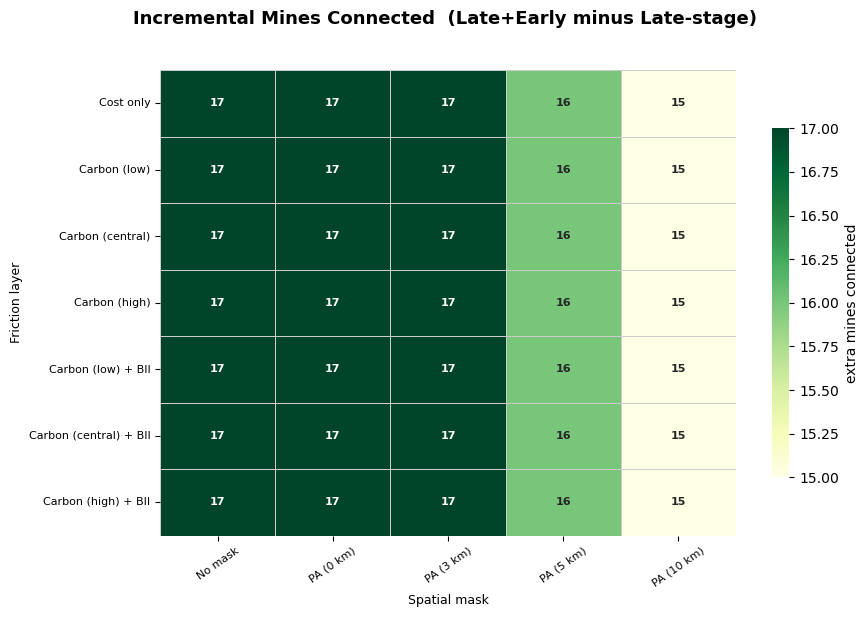

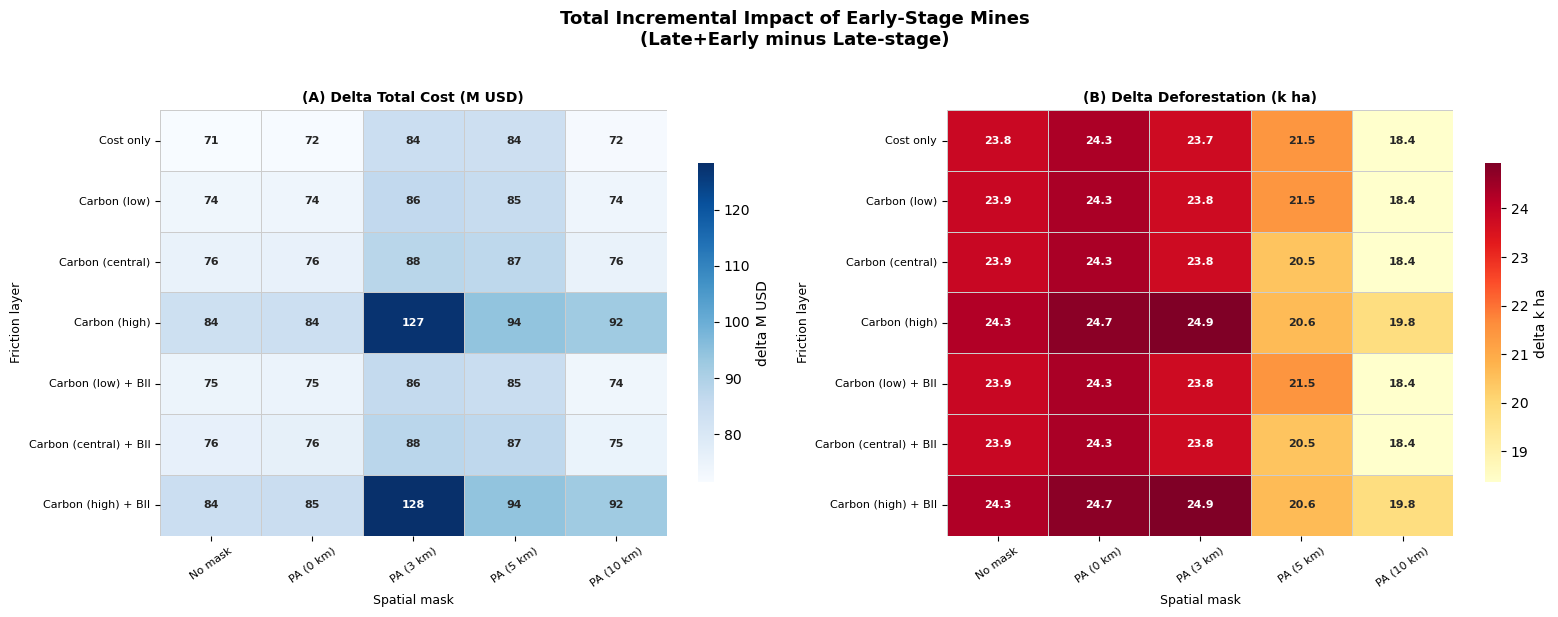

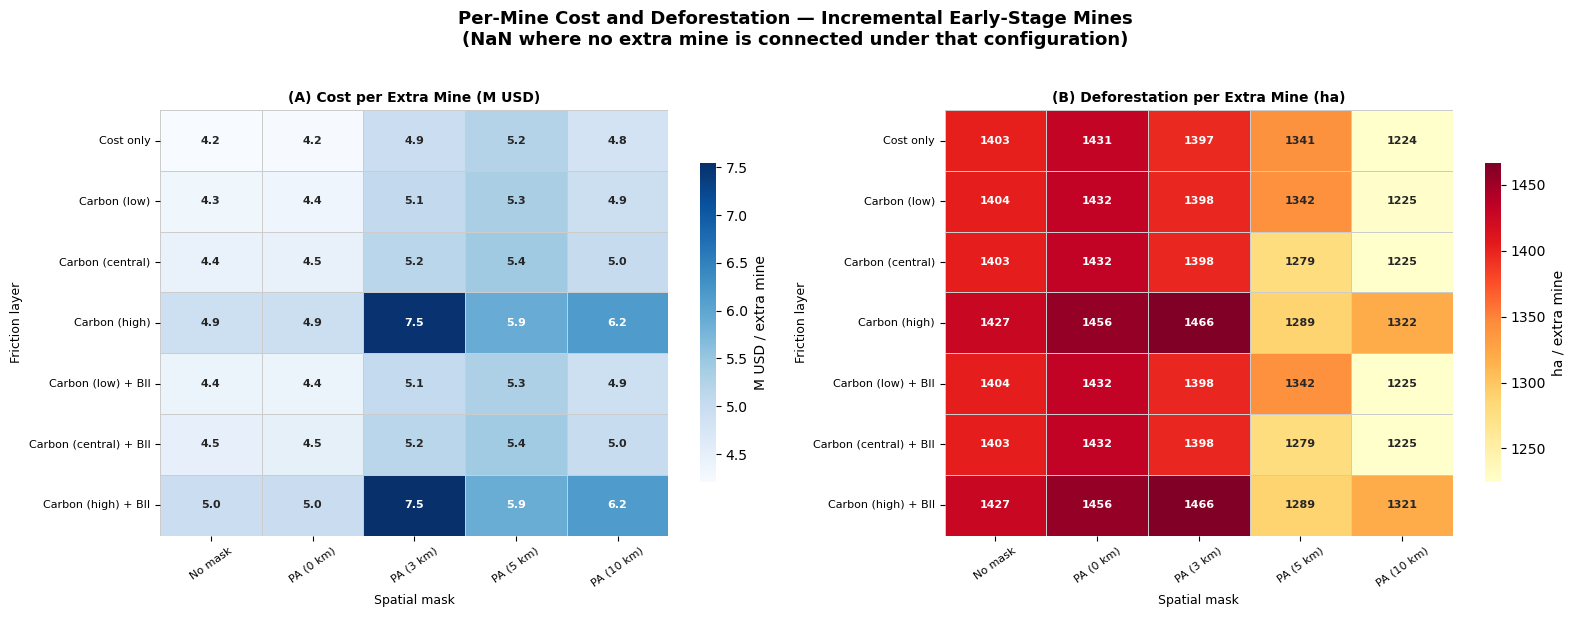

In [32]:
def single_hm(ax, df, col, cmap, fmt, cbar_label='', diverging=False, title=''):
    """Single friction x mask heatmap (not split by mining scope)."""
    pv = (
        df.pivot(index='friction', columns='mask', values=col)
          .reindex(index=FRICTION_ORDER, columns=MASK_ORDER)
    )
    pv.index   = [FRICTION_LABELS[f] for f in FRICTION_ORDER]
    pv.columns = [MASK_LABELS[m]     for m in MASK_ORDER]
    vals = df[col].dropna().values
    kw = {}
    if diverging:
        fin  = vals[np.isfinite(vals)]
        vmax = float(np.abs(fin).max()) if len(fin) else 1.0
        kw   = dict(center=0.0, vmin=-vmax, vmax=vmax)
    sns.heatmap(
        pv, ax=ax, cmap=cmap, annot=True, fmt=fmt,
        linewidths=0.4, linecolor='#ccc',
        cbar_kws={'shrink': 0.75, 'label': cbar_label},
        annot_kws={'size': 8, 'fontweight': 'bold'}, **kw,
    )
    ax.set_xlabel('Spatial mask', fontsize=9)
    ax.set_ylabel('Friction layer', fontsize=9)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
    if title:
        ax.set_title(title, fontsize=10, fontweight='bold')


# ── Merge late vs. late+early to compute incremental impact ───────────────────
late_df   = all_df[all_df['mining'] == 'late_stage'].copy()
learly_df = all_df[all_df['mining'] == 'late_and_early_stage'].copy()
merged    = late_df.merge(learly_df, on=['friction', 'mask'], suffixes=('_late', '_le'))

incr = merged[['friction', 'mask']].copy()
incr['friction'] = pd.Categorical(incr['friction'], FRICTION_ORDER, ordered=True)
incr['mask']     = pd.Categorical(incr['mask'],     MASK_ORDER,     ordered=True)
incr['delta_mines']     = merged['n_mines_accessible_le'] - merged['n_mines_accessible_late']
incr['delta_cost_musd'] = merged['total_cost_musd_le']    - merged['total_cost_musd_late']
incr['delta_defor_kha'] = merged['defor_action_kha_le']   - merged['defor_action_kha_late']
incr['delta_fi_e6']     = merged['delta_fi_e6_le']        - merged['delta_fi_e6_late']

safe_mines = incr['delta_mines'].replace(0, np.nan)
incr['cost_per_incr_mine_musd'] = incr['delta_cost_musd'] / safe_mines
incr['defor_per_incr_mine_ha']  = incr['delta_defor_kha'] * 1000.0 / safe_mines

print(f'Early-stage mines added: min={incr["delta_mines"].min():.0f}, '
      f'max={incr["delta_mines"].max():.0f}, '
      f'median={incr["delta_mines"].median():.0f}')

# ── How many incremental mines are connected? ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle('Incremental Mines Connected  (Late+Early minus Late-stage)',
             fontsize=13, fontweight='bold', y=1.02)
single_hm(ax, incr, 'delta_mines', cmap='YlGn', fmt='.0f',
          cbar_label='extra mines connected')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7a_incr_delta_mines.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Total incremental cost and deforestation ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Total Incremental Impact of Early-Stage Mines\n(Late+Early minus Late-stage)',
             fontsize=13, fontweight='bold', y=1.02)
single_hm(axes[0], incr, 'delta_cost_musd',
          cmap='Blues', fmt='.0f', cbar_label='delta M USD',
          title='(A) Delta Total Cost (M USD)')
single_hm(axes[1], incr, 'delta_defor_kha',
          cmap='YlOrRd', fmt='.1f', cbar_label='delta k ha',
          title='(B) Delta Deforestation (k ha)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7b_incr_cost_defor.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per incremental mine ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Per-Mine Cost and Deforestation — Incremental Early-Stage Mines\n'
             '(NaN where no extra mine is connected under that configuration)',
             fontsize=13, fontweight='bold', y=1.02)
single_hm(axes[0], incr, 'cost_per_incr_mine_musd',
          cmap='Blues', fmt='.1f', cbar_label='M USD / extra mine',
          title='(A) Cost per Extra Mine (M USD)')
single_hm(axes[1], incr, 'defor_per_incr_mine_ha',
          cmap='YlOrRd', fmt='.0f', cbar_label='ha / extra mine',
          title='(B) Deforestation per Extra Mine (ha)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7c_incr_per_mine.png', dpi=150, bbox_inches='tight')
plt.show()

<p style="color: #1565c0; font-style: italic;">Add notes</p>

## 8. Patch Size Distribution — Representative Scenarios

Forest patch size distribution (action state) for selected representative scenarios.
Compares across friction layers for a fixed mining scope and no-mask condition.

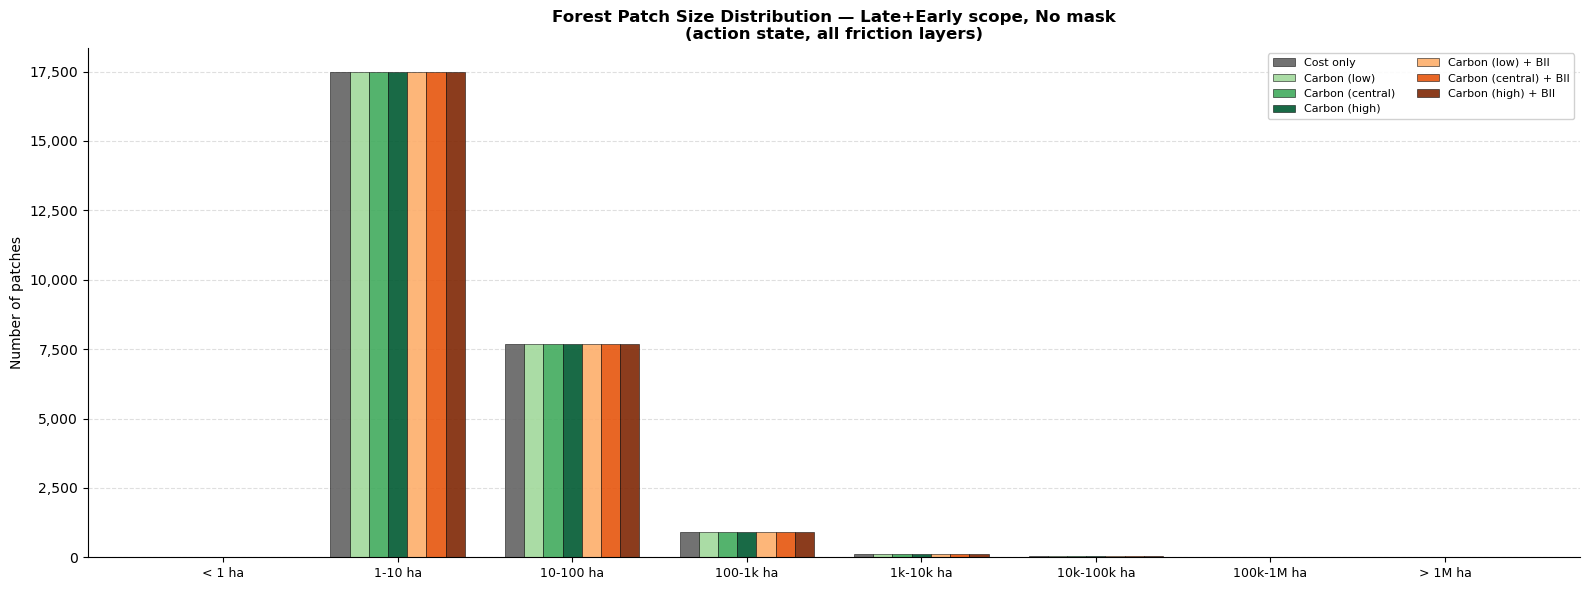

In [33]:
# Representative subset: late_and_early_stage, no_mask, all friction layers
rep_df = all_df[
    (all_df['mining'] == 'late_and_early_stage') &
    (all_df['mask']   == 'no_mask')
].copy()

bin_keys   = [k for k, _ in SIZE_BINS]
bin_labels = [l for _, l in SIZE_BINS]
n_bins     = len(SIZE_BINS)
n_scen     = len(FRICTION_ORDER)
bw         = 0.11
offsets    = np.linspace(-(n_scen - 1) * bw / 2, (n_scen - 1) * bw / 2, n_scen)

fig, ax = plt.subplots(figsize=(16, 6))
ax.set_title(
    'Forest Patch Size Distribution — Late+Early scope, No mask\n(action state, all friction layers)',
    fontweight='bold', fontsize=12,
)

for j, friction in enumerate(FRICTION_ORDER):
    row = rep_df[rep_df['friction'] == friction]
    if row.empty:
        continue
    row = row.iloc[0]
    vals = [row[f'frag_patch_size_dis_{k}_n'] for k in bin_keys]
    ax.bar(
        np.arange(n_bins) + offsets[j], vals, bw,
        color=FRICTION_COLORS[friction], edgecolor='black', linewidth=0.4,
        label=FRICTION_LABELS[friction], alpha=0.9,
    )

ax.set_xticks(np.arange(n_bins))
ax.set_xticklabels(bin_labels, fontsize=9)
ax.set_ylabel('Number of patches')
ax.legend(fontsize=8, frameon=True, framealpha=0.9, ncol=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7_patch_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<p style="color: #1565c0; font-style: italic;">Add notes</p>

## 9. Spatial Road Networks — No Mask Scenarios

Side-by-side maps comparing the full road network for each friction layer under the no-mask condition.
**Gray** = full mine-to-port path (including paved segments already maintained).
**Blue** = upgrade (existing unpaved road to be paved).
**Orange** = new build (no existing road).

Each column is one friction layer; each row is a mining scope.

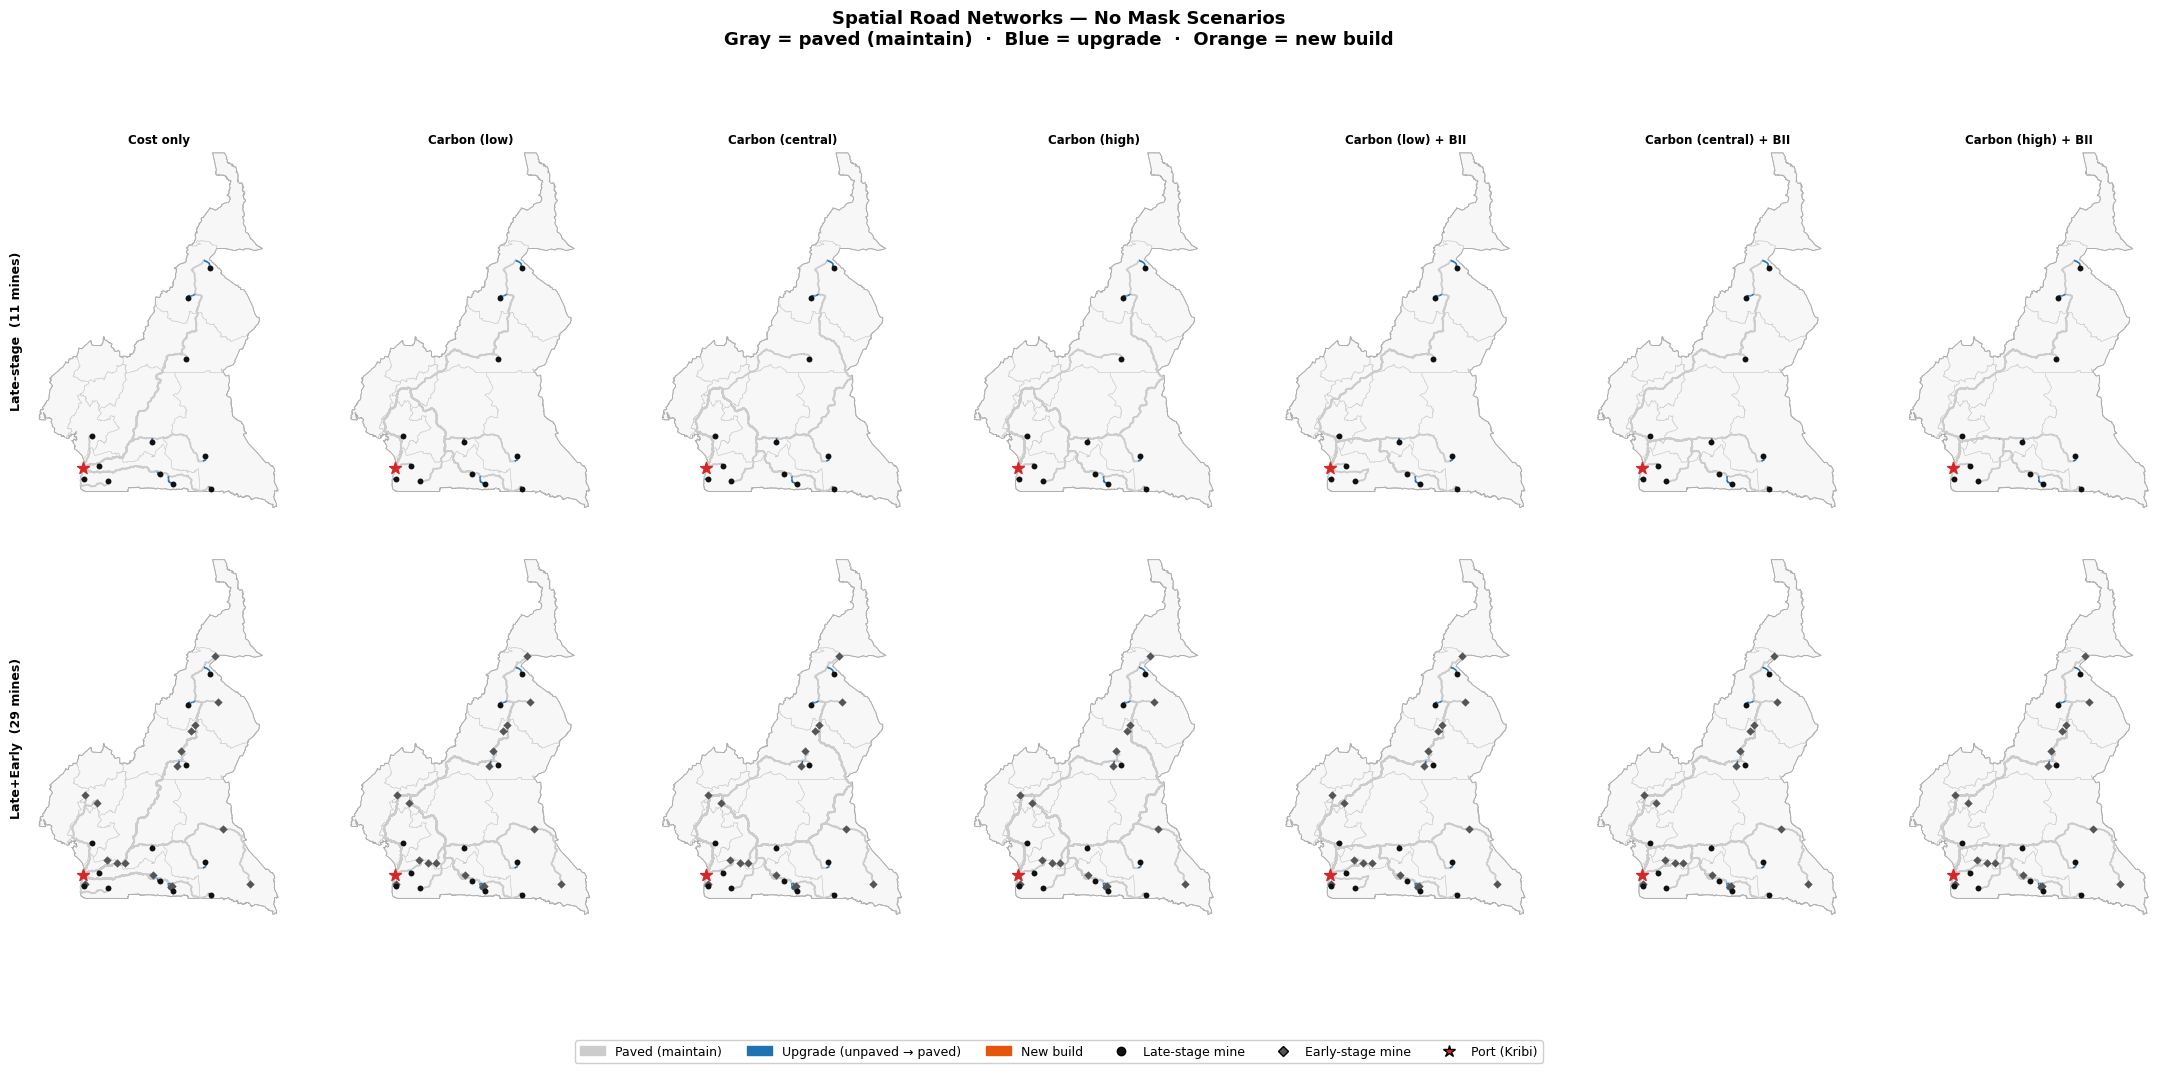

Saved → ..\model\results\impact-assessment\experiment_02_70runs\figures\fig9_spatial_maps_no_mask.png


In [34]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# ── Paths (relative to result-analysis/) ─────────────────────────────────────
_ASSESS_DIR = Path('../model/results/impact-assessment/experiment_02_70runs')
_PATHS_DIR  = Path('../model/results/least-cost-paths/experiment_02_70runs')
_DATA_DIR   = Path('../data')

# Cameroon boundaries
cmr_adm0 = gpd.read_file(_DATA_DIR / 'input/cmr_admin_boundaries_humdata/cmr_admin0_em.shp')
cmr_adm1 = gpd.read_file(_DATA_DIR / 'input/cmr_admin_boundaries_humdata/cmr_admin1_em.shp')

# Mines
_mines_df  = pd.read_csv(_DATA_DIR / 'output/cmr-mine-locations/all_mines_with_id.csv')
late_mines  = _mines_df[_mines_df['DEV_STAGE_AGGREGATED_SNL'] == 'Late-stage']
early_mines = _mines_df[_mines_df['DEV_STAGE_AGGREGATED_SNL'] == 'Early-stage']

# Port
PORTS = {'Kribi': (9.910192, 2.940594)}   # lon, lat

# Cameroon bounding box (with small margin)
XLIM = (8.3,  16.4)
YLIM = (1.5,  13.2)

# Colors
_PAVED_C   = '#cccccc'
_UPGRADE_C = '#2171b5'
_BUILD_C   = '#e6550d'

# ── Figure: 2 rows (mining scope) × 7 cols (friction layer) ──────────────────
fig, axes = plt.subplots(
    2, 7,
    figsize=(28, 10),
    gridspec_kw={'wspace': 0.04, 'hspace': 0.12},
)
fig.suptitle('Spatial Road Networks — No Mask Scenarios\n'
             'Gray = paved (maintain)  ·  Blue = upgrade  ·  Orange = new build',
             fontsize=13, fontweight='bold', y=1.02)

for row_i, mining in enumerate(MINING_ORDER):
    for col_i, friction in enumerate(FRICTION_ORDER):
        ax = axes[row_i, col_i]

        # Cameroon background
        cmr_adm0.plot(ax=ax, color='#f7f7f7', edgecolor='#888', linewidth=0.6, zorder=1)
        cmr_adm1.plot(ax=ax, color='none',    edgecolor='#ccc', linewidth=0.3, zorder=2)

        stem = f'{mining}__kribi__{friction}__no_mask__ds1'

        # Full mine-to-port path in gray (provides paved context)
        full_fp = _PATHS_DIR / f'{stem}.gpkg'
        if full_fp.exists():
            full_gdf = gpd.read_file(full_fp)
            full_gdf[full_gdf.geometry.notna()].plot(
                ax=ax, color=_PAVED_C, linewidth=1.2, zorder=3)

        # Action roads: upgrade (blue) and new build (orange)
        action_fp = _ASSESS_DIR / f'{stem}__action_roads.gpkg'
        if action_fp.exists():
            act     = gpd.read_file(action_fp)
            upgrade = act[act['action_needed'] == 'upgrade']
            build   = act[act['action_needed'] == 'build']
            if not upgrade.empty:
                upgrade.plot(ax=ax, color=_UPGRADE_C, linewidth=1.0, zorder=4)
            if not build.empty:
                build.plot(ax=ax, color=_BUILD_C, linewidth=1.0, zorder=4)

        # Mine locations
        mines_show = (
            late_mines if mining == 'late_stage'
            else pd.concat([late_mines, early_mines])
        )
        ax.scatter(late_mines['LONGITUDE'], late_mines['LATITUDE'],
                   s=18, c='#111', zorder=6, marker='o', linewidths=0)
        if mining == 'late_and_early_stage':
            ax.scatter(early_mines['LONGITUDE'], early_mines['LATITUDE'],
                       s=18, c='#555', zorder=5, marker='D', linewidths=0)

        # Port
        for lon, lat in PORTS.values():
            ax.scatter(lon, lat, s=80, c='#d62728', zorder=7, marker='*')

        ax.set_xlim(XLIM)
        ax.set_ylim(YLIM)
        ax.set_aspect('equal')
        ax.axis('off')

        if row_i == 0:
            ax.set_title(FRICTION_LABELS[friction], fontsize=8.5,
                         fontweight='bold', pad=4)

    # Row label on left side
    axes[row_i, 0].annotate(
        MINING_LABELS[mining],
        xy=(-0.04, 0.5), xycoords='axes fraction',
        fontsize=9, fontweight='bold', rotation=90,
        ha='right', va='center',
    )

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=_PAVED_C,   label='Paved (maintain)'),
    mpatches.Patch(color=_UPGRADE_C, label='Upgrade (unpaved → paved)'),
    mpatches.Patch(color=_BUILD_C,   label='New build'),
    mlines.Line2D([], [], marker='o', color='none', markerfacecolor='#111',
                  markersize=6, label='Late-stage mine'),
    mlines.Line2D([], [], marker='D', color='none', markerfacecolor='#555',
                  markersize=5, label='Early-stage mine'),
    mlines.Line2D([], [], marker='*', color='none', markerfacecolor='#d62728',
                  markersize=9, label='Port (Kribi)'),
]
fig.legend(
    handles=legend_handles,
    loc='lower center', bbox_to_anchor=(0.5, -0.04),
    ncol=6, fontsize=9, frameon=True, framealpha=0.95,
)

plt.savefig(FIGURES_DIR / 'fig9_spatial_maps_no_mask.png',
            dpi=180, bbox_inches='tight')
plt.show()
print(f"Saved → {FIGURES_DIR / 'fig9_spatial_maps_no_mask.png'}")